# **Notebook 01: Ingesta de datos, extracción con IA generativa y descarga de imágenes**

**Proyecto:** VALORALIA Systems

**Autora:** María Luisa Ros Bolea



He vuelto a vaciar todas las subcarpetas de mi Google Drive para empezar la extracción desde cero absoluto. Tras demasiadas iteraciones y más de un toque de atención de mi tutor Miguel, tengo claro que el 80% de un buen modelo predictivo es tener un conjunto de datos **dataset**, que es una colección estructurada de información que sirve como base para entrenar modelos de IA, totalmente impecable. Hasta que eso no esté resuelto, no tiene sentido hablar de algoritmos.

En versiones anteriores cometí errores graves que no voy a repetir. El primero: usaba condicionales básicos para rellenar variables como ascensor o terraza. Si el texto no mencionaba la palabra, mi código ponía un cero, lo cual equivale a inventar datos. Un cero significa "no tiene ascensor", pero lo correcto cuando no hay información es "Desconocido". El segundo error: mi código leía la ficha técnica y cogía el primer número que encontraba. El resultado: 115 habitaciones en la planta 115. El tercer error, y el que más tiempo me ha quitado: la descripción del anuncio salía nula en demasiados registros, lo que inutilizaba el paso de la Inteligencia Artificial. Ahora sé que el texto está en las meta etiquetas de la página como me mostró Miguel en la última videollamada, y esa va a ser mi primera línea de ataque.

En este cuaderno corrijo todo de raíz:

1. Las variables cualitativas (ascensor, terraza, garaje, calefacción, estado de reforma) las extrae un modelo de lenguaje grande **Large Language Model**, que es un algoritmo de inteligencia artificial generativa entrenado con cantidades masivas de texto para comprender y generar lenguaje humano. Concretamente, usaré, como me recomendaron, la interfaz de programación de aplicaciones **API**, que es un conjunto de reglas y protocolos que permite a diferentes programas comunicarse entre sí, de Gemini Flash de Google.

2. Las variables numéricas (habitaciones, planta, baños) se extraen con expresiones regulares **regular expressions**, que son secuencias de caracteres que conforman un patrón de búsqueda estricto para encontrar coincidencias específicas en un texto.

3. Las imágenes se extraen del código fuente crudo, porque la web usa carga perezosa **lazy loading**, que es un patrón de diseño web que retrasa la descarga de un objeto hasta el momento exacto en que se necesita, ocultándolo del código HTML inicial.

4. La descripción del anuncio se extrae con un método en cascada de cuatro niveles, garantizando que nunca devuelva un valor nulo, o al menos eso estoy intentando y espero que ya se cumpla.

¿Por qué no tiré del anterior CSV que tenías sus URL como dijo Miguel? Pues porque no me vi con la confianza suficiente de crear las columnas sin cometer ningún error y, sinceramente, tampoco que las imagenes se guardasen ordenadamente o sin duplicados y preferí limpiar todo e drive y comenzar de nuevo y así aprovechr por si podía incluso coneguir nuevos pisos (aunque eso significase empezar de nuevo por 3º vez)

## **1. Configuración del entorno y conexión a Google Drive**

Instalo las dependencias, conecto mi Drive y creo la estructura de carpetas desde cero. Para que la extracción pueda ejecutarse de madrugada sin detenerse a pedir contraseñas, utilizo la herramienta de secretos **Secrets**, que es una función de Google Colab para almacenar variables privadas de forma segura, donde he guardado mi clave de Gemini bajo el nombre `GEMINI_API_KEY`.

In [ ]:
!pip install -q beautifulsoup4 lxml Pillow tqdm fake-useragent google-generativeai
print('Dependencias instaladas.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 4.2 MB/s eta 0:00:00
Dependencias instaladas.


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import google.generativeai as genai
import time, random, os, re, json, hashlib
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm
from PIL import Image
from io import BytesIO
from fake_useragent import UserAgent
import warnings
warnings.filterwarnings('ignore')

ua = UserAgent()
print(f'Entorno listo. {datetime.now().strftime("%Y-%m-%d %H:%M")}')

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Entorno listo. 2026-03-18 11:37


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/TFM_VALORALIA_3'
for sub in ['01_Datos_Crudos', '02_Datos_Procesados', '03_Imagenes_Multiples']:
    os.makedirs(f'{BASE_DIR}/{sub}', exist_ok=True)

print(f'Estructura creada en: {BASE_DIR}')
for sub in sorted(os.listdir(BASE_DIR)):
    print(f'  /{sub}')

Mounted at /content/drive
Estructura creada en: /content/drive/MyDrive/TFM_VALORALIA_3
  /01_Datos_Crudos
  /02_Datos_Procesados
  /03_Imagenes_Multiples


## **2. Extracción web a prueba de balas**

Después de comprobar que Idealista bloquea cualquier intento de extracción web **web scraping**, que es una técnica automatizada mediante programas de software para extraer información de sitios web, la decisión técnica fue usar Pisos.com. Este es el segundo portal inmobiliario de España y cuenta con renderizado en el servidor **server-side rendering**, que es una técnica donde el servidor web genera el código HTML completo antes de enviarlo al navegador del usuario, lo que me permite procesarlo sin necesidad de usar librerías pesadas como Selenium. He navegado las 42 zonas a mano y he copiado cada URL individualmente.

Las correcciones críticas de esta versión son cinco:

* Expresiones regulares estrictas (Regla 2): para las habitaciones busco SOLO números pegados a "hab" o "dormit". Para la planta, SOLO números pegados a "planta". Para "planta baja", exijo que "planta" aparezca obligatoriamente delante de "baja".

* Descripción infalible (Regla 4): cascada de cuatro niveles con mecanismo de respaldo **fallback**, que es un sistema alternativo de seguridad que se activa automáticamente cuando el método principal falla. Primero busca en las meta etiquetas **meta tags**, que son fragmentos de código HTML en el encabezado de una página que proporcionan metadatos a los motores de búsqueda. Luego, busca selectores CSS; después, datos vinculados **JSON-LD**, que es un formato estándar de código incrustado para estructurar datos web; y como último recurso, el párrafo más largo. Así, junto con la API, conseguiré la descripción que nos propusimos en la última tutoría.

* Imágenes del código fuente (Regla 3): escaneo del HTML crudo buscando URLs específicas para saltarme la carga perezosa.

* Manejo de errores sin ocultación (Regla 5): si un anuncio falla, guardo un registro con nulos para que el sistema de puntos de control **checkpoints**, que son copias de seguridad físicas que se guardan periódicamente para no perder el progreso si se interrumpe la ejecución, no se rompa ni entre en bucles infinitos.

* Cero invención de variables (Regla 1): ascensor, terraza, garaje, calefacción y estado de reforma se delegan íntegramente a Gemini, nada de cargarnos variales o poner 0 o 1 porque sí.

In [ ]:
ZONAS = {
    'Centro': 'https://www.pisos.com/venta/pisos-madrid_capital_centro/',
    'Arganzuela': 'https://www.pisos.com/venta/pisos-arganzuela_distrito/',
    'Retiro': 'https://www.pisos.com/venta/pisos-madrid_capital_retiro/',
    'Salamanca': 'https://www.pisos.com/venta/pisos-madrid_capital_salamanca/',
    'Chamartin': 'https://www.pisos.com/venta/pisos-madrid_capital_chamartin/',
    'Tetuan': 'https://www.pisos.com/venta/piso-tetuan/',
    'Chamberi': 'https://www.pisos.com/venta/piso-chamberi_distrito/',
    'Fuencarral': 'https://www.pisos.com/venta/piso-fuencarral_el_pardo/',
    'Moncloa': 'https://www.pisos.com/venta/pisos-moncloa_aravaca/',
    'Latina': 'https://www.pisos.com/venta/pisos-latina/',
    'Carabanchel': 'https://www.pisos.com/venta/pisos-madrid_capital_carabanchel/',
    'Usera': 'https://www.pisos.com/venta/pisos-madrid_capital_usera/',
    'Puente_Vallecas': 'https://www.pisos.com/venta/pisos-puente_de_vallecas/',
    'Moratalaz': 'https://www.pisos.com/venta/pisos-moratalaz/',
    'Ciudad_Lineal': 'https://www.pisos.com/venta/piso-ciudad_lineal/',
    'Hortaleza': 'https://www.pisos.com/venta/pisos-hortaleza_distrito/',
    'Villaverde': 'https://www.pisos.com/venta/pisos-villaverde_distrito/',
    'Villa_Vallecas': 'https://www.pisos.com/venta/pisos-villa_de_vallecas/',
    'Vicalvaro': 'https://www.pisos.com/venta/pisos-madrid_capital_vicalvaro/',
    'San_Blas': 'https://www.pisos.com/venta/pisos-madrid_capital_san_blas/',
    'Barajas': 'https://www.pisos.com/venta/pisos-barajas_distrito/',
    'Alcobendas': 'https://www.pisos.com/venta/pisos-alcobendas/',
    'SS_Reyes': 'https://www.pisos.com/venta/pisos-san_sebastian_de_los_reyes/',
    'Tres_Cantos': 'https://www.pisos.com/venta/pisos-tres_cantos/',
    'Colmenar_Viejo': 'https://www.pisos.com/venta/pisos-colmenar_viejo/',
    'Getafe': 'https://www.pisos.com/venta/pisos-getafe/',
    'Leganes': 'https://www.pisos.com/venta/pisos-leganes/',
    'Alcorcon': 'https://www.pisos.com/venta/pisos-alcorcon/',
    'Mostoles': 'https://www.pisos.com/venta/pisos-mostoles/',
    'Fuenlabrada': 'https://www.pisos.com/venta/pisos-fuenlabrada/',
    'Parla': 'https://www.pisos.com/venta/pisos-parla/',
    'Pinto': 'https://www.pisos.com/venta/pisos-pinto/',
    'Torrejon': 'https://www.pisos.com/venta/pisos-torrejon_de_ardoz/',
    'Alcala_Henares': 'https://www.pisos.com/venta/pisos-alcala_de_henares/',
    'Coslada': 'https://www.pisos.com/venta/pisos-coslada/',
    'Rivas': 'https://www.pisos.com/venta/pisos-rivas-vaciamadrid/',
    'Arganda': 'https://www.pisos.com/venta/pisos-arganda_del_rey/',
    'Pozuelo': 'https://www.pisos.com/venta/pisos-pozuelo_de_alarcon/',
    'Las_Rozas': 'https://www.pisos.com/venta/pisos-las_rozas_de_madrid/',
    'Majadahonda': 'https://www.pisos.com/venta/pisos-majadahonda/',
    'Boadilla': 'https://www.pisos.com/venta/pisos-boadilla_del_monte/',
    'Villaviciosa_Odon': 'https://www.pisos.com/venta/pisos-villaviciosa_de_odon/',
}
print(f'Zonas: {len(ZONAS)} (21 distritos + {len(ZONAS)-21} corona metropolitana)')

Zonas: 42 (21 distritos + 21 corona metropolitana)


In [ ]:
class ScraperPisos:
    """Scraper para pisos.com. requests + BS4, sin Selenium."""

    def __init__(self):
        self.session = requests.Session()
        self._renovar_cabeceras()
        self.bloqueos = 0
        self.peticiones = 0

    def _renovar_cabeceras(self):
        self.session.headers.update({
            'User-Agent': ua.random,
            'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9',
            'Accept-Language': 'es-ES,es;q=0.9',
            'Accept-Encoding': 'gzip, deflate, br',
            'Connection': 'keep-alive',
        })

    def get(self, url, max_reintentos=3):
        for intento in range(max_reintentos):
            try:
                self.session.headers['User-Agent'] = ua.random
                self.peticiones += 1
                r = self.session.get(url, timeout=20)
                if r.status_code == 200:
                    return r
                if r.status_code in [403, 429, 503]:
                    self.bloqueos += 1
                    pausa = 30 * (intento + 1)
                    print(f'\n  [!] Bloqueo {r.status_code}. Pausa {pausa}s...')
                    time.sleep(pausa)
                    self.session = requests.Session()
                    self._renovar_cabeceras()
                    continue
                return None
            except requests.exceptions.Timeout:
                time.sleep(5)
            except Exception:
                time.sleep(3)
        return None

    # REGEX ESTRICTAS (Regla 2)

    def _extraer_superficie(self, texto):
        for patron in [r'(\d+)\s*m\s*[\u00b2\xb2]', r'(\d+)\s*m2',
                       r'superficie[:\s]*(\d+)', r'(\d+)\s*metros']:
            m = re.search(patron, texto, re.IGNORECASE)
            if m:
                val = int(m.group(1))
                if 10 <= val <= 2000:
                    return val
        return None

    def _extraer_habitaciones(self, texto):
        for patron in [r'(\d+)\s*(?:hab|dormit)', r'(?:hab|dormit)\w*[:\s]+(\d+)']:
            m = re.search(patron, texto, re.IGNORECASE)
            if m:
                val = int(m.group(1))
                if 1 <= val <= 12:
                    return val
        return None

    def _extraer_banos(self, texto):
        for patron in [r'(\d+)\s*(?:ba[\u00f1n]o|aseo|wc)',
                       r'(?:ba[\u00f1n]o|aseo|wc)\w*[:\s]+(\d+)']:
            m = re.search(patron, texto, re.IGNORECASE)
            if m:
                val = int(m.group(1))
                if 1 <= val <= 8:
                    return val
        return None

    def _extraer_planta(self, texto):
        for patron in [r'(\d+)[\u00aa\u00baaero\u00ba]*\s*planta',
                       r'planta\s*(\d+)',
                       r'(\d+)[\u00aa\u00baaero\u00ba]\s*(?:piso|pla)']:
            m = re.search(patron, texto, re.IGNORECASE)
            if m:
                val = int(m.group(1))
                if 0 <= val <= 40:
                    return val
        if re.search(r'planta\s+baj[oa]', texto, re.IGNORECASE):
            return 0
        return None

    # IMAGENES del codigo fuente crudo (Regla 3)

    def _extraer_imagenes_fuente(self, html_crudo):
        patron = r'https?://fotos\.imghs\.net/[^\s"\\<>]+?\.(?:jpg|jpeg|webp|png)'
        urls_raw = re.findall(patron, html_crudo, re.IGNORECASE)
        urls_limpias = [u.replace('\\/', '/').replace('\\', '') for u in urls_raw]
        vistas = set()
        unicas = []
        for u in urls_limpias:
            if u not in vistas and 'fotos.imghs.net' in u:
                vistas.add(u)
                unicas.append(u)
        return unicas[:20]

    # DESCRIPCION INFALIBLE: cascada de 4 niveles (Regla 4)

    def _limpiar_boilerplate(self, texto):
        if not texto:
            return ''
        texto = re.sub(r'^[Aa]ccede a la vista 3[Dd][^.]*\.\s*', '', texto).strip()
        return texto

    def _extraer_descripcion(self, soup):
        # NIVEL 1: META TAGS SEO (lo mas fiable)
        for meta in [
            soup.find('meta', attrs={'name': 'description'}),
            soup.find('meta', attrs={'property': 'og:description'}),
            soup.find('meta', attrs={'name': 'twitter:description'}),
        ]:
            if meta and meta.get('content'):
                texto = self._limpiar_boilerplate(meta['content'].strip())
                if len(texto) > 30:
                    return texto[:3000]

        # NIVEL 2: SELECTORES CSS
        for selector in ['.description', '#description', '[class*="description"]',
                         '.js-description', '.p-desc', '[itemprop="description"]',
                         '.detail-description', '.comment']:
            el = soup.select_one(selector)
            if el:
                texto = self._limpiar_boilerplate(el.get_text(strip=True))
                if len(texto) > 30:
                    return texto[:3000]

        # NIVEL 3: JSON-LD
        for script in soup.find_all('script', type='application/ld+json'):
            try:
                ld = json.loads(script.string)
                if isinstance(ld, list):
                    ld = ld[0]
                if isinstance(ld, dict) and 'description' in ld:
                    texto = self._limpiar_boilerplate(str(ld['description']).strip())
                    if len(texto) > 30:
                        return texto[:3000]
            except Exception:
                continue

        # NIVEL 4: PARRAFO MAS LARGO
        mejor = ''
        for tag in soup.find_all(['p', 'div', 'span']):
            texto = self._limpiar_boilerplate(tag.get_text(strip=True))
            if len(texto) > len(mejor) and len(texto) > 50:
                if not any(x in texto.lower()[:30] for x in ['cookie', 'copyright', 'navegaci', 'javascript']):
                    mejor = texto
        if len(mejor) > 30:
            return mejor[:3000]

        return 'Sin descripcion disponible'

    # PARSEO

    def parsear_listado(self, url_pagina):
        r = self.get(url_pagina)
        if not r:
            return []
        soup = BeautifulSoup(r.text, 'lxml')
        anuncios = []
        cards = (soup.select('.ad-preview') or soup.select('.ad-card') or
                 soup.select('[class*="ad-preview"]') or soup.select('article'))
        for card in cards:
            try:
                enlace = (card.select_one('a.ad-preview__title') or
                          card.select_one('a[class*="title"]') or
                          card.find('a', href=True))
                if not enlace or not enlace.get('href'):
                    continue
                href = enlace['href']
                url_det = f'https://www.pisos.com{href}' if href.startswith('/') else href
                if not url_det.startswith('http'):
                    continue
                anuncios.append({
                    'id_anuncio': hashlib.md5(url_det.encode()).hexdigest()[:12],
                    'url': url_det,
                    'titulo': enlace.get_text(strip=True),
                    'zona_scraping': '',
                })
            except Exception:
                continue
        return anuncios

    def parsear_detalle(self, url, zona=''):
        datos = {
            'id_anuncio': hashlib.md5(url.encode()).hexdigest()[:12],
            'url': url, 'zona_scraping': zona, 'fuente': 'pisos.com',
            'fecha_scraping': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'precio': np.nan, 'titulo': np.nan, 'tipo_inmueble': 'piso',
            'superficie_m2': np.nan, 'habitaciones': np.nan,
            'banos': np.nan, 'planta': np.nan, 'descripcion': np.nan,
            'url_imagen_principal': np.nan, 'urls_imagenes': np.nan, 'num_imagenes': 0,
        }
        r = self.get(url)
        if not r:
            datos['descripcion'] = 'Sin descripcion disponible'
            return datos

        html_crudo = r.text
        soup = BeautifulSoup(html_crudo, 'lxml')

        # PRECIO
        for sel in ['.price', '[class*="price"]', '.h1-simulated', 'h1']:
            el = soup.select_one(sel)
            if el:
                nums = re.findall(r'[\d]+', el.get_text().replace('.', ''))
                if nums and int(nums[0]) > 10000:
                    datos['precio'] = int(nums[0])
                    break

        # TITULO Y TIPO
        t_el = soup.select_one('h1, .title, .main-title')
        if t_el:
            datos['titulo'] = t_el.get_text(strip=True)
            tl = datos['titulo'].lower()
            for kw, tipo in [('atico','atico'),('tico','atico'),('duplex','duplex'),
                             ('estudio','estudio'),('chalet','chalet'),
                             ('adosado','chalet'),('piso','piso')]:
                if kw in tl:
                    datos['tipo_inmueble'] = tipo
                    break

        # VARIABLES NUMERICAS: REGEX ESTRICTAS
        bloques = [el.get_text(strip=True) for el in
                   soup.select('li, dd, dt, .charblock-detail li, '
                               '[class*="feature"], [class*="char"]')]
        bloques.append(soup.get_text(' ', strip=True))
        for bloque in bloques:
            if pd.isna(datos['superficie_m2']):
                s = self._extraer_superficie(bloque)
                if s: datos['superficie_m2'] = s
            if pd.isna(datos['habitaciones']):
                h = self._extraer_habitaciones(bloque)
                if h: datos['habitaciones'] = h
            if pd.isna(datos['banos']):
                b = self._extraer_banos(bloque)
                if b: datos['banos'] = b
            if pd.isna(datos['planta']):
                p = self._extraer_planta(bloque)
                if p is not None: datos['planta'] = p

        # CODIGO POSTAL
        texto_pagina = soup.get_text(' ', strip=True)
        cp = re.search(r'\b(28\d{3})\b', texto_pagina)
        if cp:
            datos['codigo_postal'] = cp.group(1)

        # DESCRIPCION INFALIBLE (Regla 4)
        datos['descripcion'] = self._extraer_descripcion(soup)

        # IMAGENES (Regla 3)
        imgs = self._extraer_imagenes_fuente(html_crudo)
        if not imgs:
            for im in soup.select('.gallery img, .carousel img, [class*="gallery"] img'):
                src = im.get('src') or im.get('data-src') or im.get('data-original')
                if src and src.startswith('http'):
                    imgs.append(src)
            if not imgs:
                for sc in soup.find_all('script', type='application/ld+json'):
                    try:
                        ld = json.loads(sc.string)
                        if isinstance(ld, dict) and 'image' in ld:
                            i = ld['image']
                            imgs = i if isinstance(i, list) else [i]
                    except Exception:
                        pass
            imgs = list(dict.fromkeys(imgs))[:20]
        datos['url_imagen_principal'] = imgs[0] if imgs else np.nan
        datos['urls_imagenes'] = '|'.join(imgs) if imgs else np.nan
        datos['num_imagenes'] = len(imgs)
        return datos

print('Clase ScraperPisos inicializada con las 5 Reglas Técnicas Críticas.')


Clase ScraperPisos inicializada con las 5 Reglas Técnicas Críticas.


## **Fase 1: Recolección de URLs de todas las zonas**

En este primer paso, el robot entra en cada una de las 42 zonas de Madrid y recopila el listado de enlaces individuales de los pisos. Guardo el estado cada 5 zonas para garantizar la trazabilidad y la reanudación segura del proceso.

In [ ]:
scraper = ScraperPisos()

ruta_ckpt = f'{BASE_DIR}/01_Datos_Crudos/_ckpt_listados.csv'
if os.path.exists(ruta_ckpt):
    df_list = pd.read_csv(ruta_ckpt)
    todos = df_list.to_dict('records')
    urls_vistas = set(df_list['url'])
    print(f'Retomando: {len(todos)}')
else:
    todos, urls_vistas = [], set()

t0 = time.time()
print(f"{'='*70}\nFASE 1: LISTADOS - {len(ZONAS)} zonas\n{'='*70}")
for idx, (zona, url_base) in enumerate(ZONAS.items()):
    print(f'[{idx+1}/{len(ZONAS)}] {zona:25s}', end=' ')
    nuevos = 0
    for pag in range(1, 51):
        url_pag = url_base if pag == 1 else f'{url_base}{pag}/'
        res = scraper.parsear_listado(url_pag)
        if not res: break
        for a in res:
            if a['url'] not in urls_vistas:
                a['zona_scraping'] = zona
                todos.append(a)
                urls_vistas.add(a['url'])
                nuevos += 1
        time.sleep(random.uniform(2.0, 4.5))
    print(f'-> {nuevos:>4d} nuevos | Total: {len(todos):>6d}')
    if (idx+1) % 5 == 0:
        pd.DataFrame(todos).to_csv(ruta_ckpt, index=False)
        print(f'  >> Checkpoint de URLs: {len(todos)}')
    time.sleep(random.uniform(3, 6))

df_list = pd.DataFrame(todos)
df_list.to_csv(ruta_ckpt, index=False)
print(f"\nFASE 1 COMPLETADA: {len(todos)} URLs | {(time.time()-t0)/60:.0f} min")

Retomando: 8102
FASE 1: LISTADOS - 42 zonas
[1/42] Centro                    ->    5 nuevos | Total:   8107
[2/42] Arganzuela                ->    0 nuevos | Total:   8107
[3/42] Retiro                    ->    3 nuevos | Total:   8110
[4/42] Salamanca                 ->    1 nuevos | Total:   8111
[5/42] Chamartin                 ->    0 nuevos | Total:   8111
  >> Checkpoint de URLs: 8111
[6/42] Tetuan                    ->    1 nuevos | Total:   8112
[7/42] Chamberi                  ->    1 nuevos | Total:   8113
[8/42] Fuencarral                ->    0 nuevos | Total:   8113
[9/42] Moncloa                   ->    0 nuevos | Total:   8113
[10/42] Latina                    ->    0 nuevos | Total:   8113
  >> Checkpoint de URLs: 8113
[11/42] Carabanchel               ->    0 nuevos | Total:   8113
[12/42] Usera                     ->    0 nuevos | Total:   8113
[13/42] Puente_Vallecas           ->    0 nuevos | Total:   8113
[14/42] Moratalaz                 ->    0 nuevos | Total:   

## **Fase 2: Extracción de detalles**

Aquí es donde el ordenador hace el trabajo pesado en paralelo. La corrección más importante que he aplicado es la eliminación de bloqueos silenciosos ciegos. Si la extracción de un anuncio genera un error, el bloque except localiza la URL exacta que ha fallado en el mapeo interno del hilo y guarda un registro lleno de valores nulos. De esta forma, el punto de control no se corrompe y evitamos bucles infinitos en futuras ejecuciones (error que ya he comedito demasiadas veces y parece que no cala en mí). Guarda rigurosamente cada piso exactos.

In [ ]:
def worker(args):
    url, zona = args
    s = ScraperPisos()
    d = s.parsear_detalle(url, zona)
    time.sleep(random.uniform(2.0, 4.0))
    return d

ruta_det = f'{BASE_DIR}/01_Datos_Crudos/_ckpt_detalles.csv'
if os.path.exists(ruta_det):
    df_d = pd.read_csv(ruta_det)
    detalles = df_d.to_dict('records')
    urls_det = set(df_d['url'])
    print(f'Retomando: {len(detalles)} previos')
else:
    detalles, urls_det = [], set()

pend = [(r['url'], r['zona_scraping']) for _, r in df_list.iterrows() if r['url'] not in urls_det]
print(f"{'='*70}\nFASE 2: EXTRACCION DE DETALLES - {len(pend)} pendientes (~{len(pend)*3.5/3/3600:.1f}h)\n{'='*70}")

t0 = time.time()
with ThreadPoolExecutor(max_workers=3) as ex:
    futs = {ex.submit(worker, a): a for a in pend}
    for i, fut in enumerate(tqdm(as_completed(futs), total=len(futs), desc='Detalles')):
        try:
            detalles.append(fut.result(timeout=30))
        except Exception as e:
            url_f, zona_f = futs[fut]
            detalles.append({
                'id_anuncio': hashlib.md5(url_f.encode()).hexdigest()[:12],
                'url': url_f, 'zona_scraping': zona_f, 'fuente': 'pisos.com',
                'fecha_scraping': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                'precio': np.nan, 'titulo': np.nan, 'tipo_inmueble': 'piso',
                'superficie_m2': np.nan, 'habitaciones': np.nan,
                'banos': np.nan, 'planta': np.nan,
                'descripcion': 'Sin descripcion disponible',
                'url_imagen_principal': np.nan, 'urls_imagenes': np.nan,
                'num_imagenes': 0, 'error': str(e)[:100]
            })

        if (i+1) % 50 == 0:
            pd.DataFrame(detalles).to_csv(ruta_det, index=False)
            el = (time.time()-t0)/60
            vel = (i+1)/el if el > 0 else 1
            print(f'\n  Ckpt {i+1}/{len(pend)} | {el:.0f}min | ETA: {(len(pend)-i-1)/vel:.0f}min')


df_det = pd.DataFrame(detalles)
df_det.to_csv(ruta_det, index=False)
print(f'\nFASE 2 COMPLETADA: {len(detalles)} detalles | {(time.time()-t0)/60:.0f} min')

df_final = df_det.copy()
li = df_list.set_index('url')
for i, row in df_final.iterrows():
    if row['url'] in li.index:
        l = li.loc[row['url']]
        for c in ['precio','superficie_m2','habitaciones','titulo']:
            if pd.isna(row.get(c)) and c in l.index and pd.notna(l[c]):
                df_final.at[i, c] = l[c]

df_final['id_anuncio'] = df_final.apply(
    lambda r: r.get('id_anuncio') if pd.notna(r.get('id_anuncio'))
    else hashlib.md5(str(r['url']).encode()).hexdigest()[:12], axis=1)

ruta_raw = f'{BASE_DIR}/01_Datos_Crudos/pisos_crudos_completos.csv'
df_final.to_csv(ruta_raw, index=False, encoding='utf-8-sig')

print(f"{'='*70}\nCSV CRUDO CONSOLIDADO: {len(df_final)} filas\n{'='*70}")
for c in ['precio','superficie_m2','habitaciones','banos','planta','descripcion','num_imagenes','zona_scraping']:
    if c in df_final.columns:
        n = df_final[c].notna().sum()
        if c == 'num_imagenes':
            print(f'  {c:25s}: media {df_final[c].mean():.1f} imgs/anuncio')
        elif c == 'descripcion':
            n_real = (df_final[c].notna() & (df_final[c] != 'Sin descripcion disponible')).sum()
            print(f'  {c:25s}: {n_real:>6d} reales ({n_real/len(df_final)*100:.1f}%)')
        else:
            print(f'  {c:25s}: {n:>6d} ({n/len(df_final)*100:.1f}%)')

mask = df_final['habitaciones'].notna() & df_final['superficie_m2'].notna() & (df_final['habitaciones'] == df_final['superficie_m2'])
print(f'\n  {"[OK] Ningun hab==sup" if mask.sum()==0 else f"[ALERTA] {mask.sum()} filas hab==sup"}')

FASE 2: EXTRACCION DE DETALLES - 8152 pendientes (~2.6h)


Detalles:   0%|          | 0/8152 [00:00<?, ?it/s]


  Ckpt 50/8152 | 1min | ETA: 168min

  Ckpt 100/8152 | 2min | ETA: 160min

  Ckpt 150/8152 | 3min | ETA: 156min

  Ckpt 200/8152 | 4min | ETA: 153min

  Ckpt 250/8152 | 5min | ETA: 151min

  Ckpt 300/8152 | 6min | ETA: 149min

  Ckpt 350/8152 | 7min | ETA: 150min

  Ckpt 400/8152 | 8min | ETA: 148min

  Ckpt 450/8152 | 9min | ETA: 148min

  Ckpt 500/8152 | 10min | ETA: 146min

  Ckpt 550/8152 | 10min | ETA: 145min

  Ckpt 600/8152 | 11min | ETA: 144min

  Ckpt 650/8152 | 12min | ETA: 143min

  Ckpt 700/8152 | 13min | ETA: 142min

  Ckpt 750/8152 | 14min | ETA: 141min

  Ckpt 800/8152 | 15min | ETA: 140min

  Ckpt 850/8152 | 16min | ETA: 139min

  Ckpt 900/8152 | 17min | ETA: 138min

  Ckpt 950/8152 | 18min | ETA: 137min

  Ckpt 1000/8152 | 19min | ETA: 136min

  Ckpt 1050/8152 | 20min | ETA: 135min

  Ckpt 1100/8152 | 21min | ETA: 135min

  Ckpt 1150/8152 | 22min | ETA: 133min

  Ckpt 1200/8152 | 23min | ETA: 133min

  Ckpt 1250/8152 | 24min | ETA: 132min

  Ckpt 1300/8152 | 25min | E

## **3. Extracción inteligente de variables con Inteligencia Artificial (Gemini)**

Ahora que tenemos descripciones largas y reales gracias a mi método de cascada infalible recomendado poe mi tutor Miguel, le pasamos cada descripción a Gemini Flash. El modelo de lenguaje lee el texto libre y clasifica cada variable como 1 (si lo menciona explícitamente), 0 (si dice que no lo tiene) o "Desconocido" (si no se menciona).

Utilizar "Desconocido" como valor base protege a nuestro modelo algorítmico de falsos negativos **false negatives**, que son errores de clasificación donde el sistema asume que una característica no existe simplemente porque la inmobiliaria olvidó mencionarla en el anuncio, cuando en realidad el piso sí podría tenerla. Esto es rigor técnico en estado puro.


In [ ]:
import json
import time
import pandas as pd
import os
import requests
from tqdm.notebook import tqdm
from google.colab import userdata

# 1. Recuperamos la clave y el directorio
if 'BASE_DIR' not in globals():
    BASE_DIR = '/content/drive/MyDrive/TFM_VALORALIA_3'

try:
    CLAVE_GEMINI = userdata.get('GEMINI_API_KEY')
except:
    CLAVE_GEMINI = globals().get('GEMINI_API_KEY', '')

if CLAVE_GEMINI:
    CLAVE_GEMINI = str(CLAVE_GEMINI).strip()

# 2. Modelos habilitados (Priorizamos el más rápido y moderno)
MODELOS_DISPONIBLES = [
    "gemini-2.5-flash",
    "gemini-2.0-flash",
    "gemini-1.5-flash"
]
modelo_activo = None

# 3. Prompt para la Inteligencia Artificial (Exigencia de Miguel)
PROMPT_GEMINI = '''Lee esta descripcion inmobiliaria y devuelveme exclusivamente un objeto JSON estricto con las siguientes claves: ascensor, terraza, garaje, calefaccion, estado_reforma.
Reglas:
- Si el texto afirma explicitamente que lo tiene, pon 1.
- Si el texto afirma explicitamente que NO lo tiene, pon 0.
- Si el texto no menciona nada sobre ese elemento, pon "Desconocido".
- NO deduzcas ni inventes datos.
- Devuelve SOLO el JSON, sin texto adicional ni backticks.
Descripcion:
{texto}'''

# 4. Función de conexión a la API (Máxima velocidad para cuenta de pago)
def extraer_variables_gemini(texto_descripcion):
    global modelo_activo

    default = {'ascensor':'Desconocido','terraza':'Desconocido',
               'garaje':'Desconocido','calefaccion':'Desconocido',
               'estado_reforma':'Desconocido'}

    try:
        if not texto_descripcion or pd.isna(texto_descripcion) or len(str(texto_descripcion).strip()) < 20:
            return default

        if texto_descripcion == 'Sin descripcion disponible':
            return default

        if not CLAVE_GEMINI:
            print("  [ERROR CRÍTICO] No se encuentra la API Key de Gemini.")
            return default

        payload = {
            "contents": [{"parts": [{"text": PROMPT_GEMINI.format(texto=str(texto_descripcion)[:2000])}]}]
        }
        headers = {'Content-Type': 'application/json'}

        # Probamos modelos hasta fijar el que tu cuenta premium tiene activo
        modelos_a_probar = [modelo_activo] if modelo_activo else MODELOS_DISPONIBLES

        for modelo_actual in modelos_a_probar:
            url = f"https://generativelanguage.googleapis.com/v1beta/models/{modelo_actual}:generateContent?key={CLAVE_GEMINI}"

            try:
                response = requests.post(url, json=payload, headers=headers, timeout=15)

                if response.status_code == 200:
                    if not modelo_activo:
                        print(f"\n  [INFO] ¡CONEXIÓN PREMIUM ACTIVA! Usando modelo: {modelo_actual}")
                        modelo_activo = modelo_actual

                    data = response.json()
                    txt = data['candidates'][0]['content']['parts'][0]['text']
                    txt = txt.strip().replace('```json','').replace('```','').strip()
                    datos = json.loads(txt)

                    for k in default:
                        if k not in datos:
                            datos[k] = 'Desconocido'
                    return datos

                elif response.status_code == 429:
                    # Incluso pagando hay límites de seguridad, si ocurre, paramos un poco
                    time.sleep(2)
                    continue
                else:
                    continue
            except:
                continue

            if modelo_activo:
                break

    except Exception as e:
        return default

    return default

# ==============================================================================
# 5. Ejecución principal del bucle a máxima potencia
# ==============================================================================

print("Cargando el archivo de pisos crudos desde Google Drive...")
ruta_crudos = f'{BASE_DIR}/01_Datos_Crudos/pisos_crudos_completos.csv'

if not os.path.exists(ruta_crudos):
    print(f"¡Error! No encuentro el archivo en {ruta_crudos}. Revisa el Notebook 01.")
else:
    df_crudo = pd.read_csv(ruta_crudos)
    n_desc = (df_crudo['descripcion'].notna() & (df_crudo['descripcion'] != 'Sin descripcion disponible')).sum()
    print(f'Total de pisos: {len(df_crudo)} | Descripciones para procesar: {n_desc}')

    ruta_gemini = f'{BASE_DIR}/02_Datos_Procesados/_ckpt_gemini.csv'

    # Recuperamos el trabajo previo si existe
    if os.path.exists(ruta_gemini):
        df_proc = pd.read_csv(ruta_gemini)
        ids_procesados = set()
        if 'ascensor' in df_proc.columns:
            ids_procesados = set(df_proc[df_proc['ascensor'] != 'Desconocido']['id_anuncio'])
        print(f'Retomando el trabajo: Ya hay {len(ids_procesados)} pisos procesados.')
    else:
        df_proc = df_crudo.copy()
        for col in ['ascensor','terraza','garaje','calefaccion','estado_reforma']:
            df_proc[col] = 'Desconocido'
        ids_procesados = set()

    pendientes = df_proc[(~df_proc['id_anuncio'].isin(ids_procesados)) &
                   (df_proc['descripcion'].notna()) &
                   (df_proc['descripcion'] != 'Sin descripcion disponible')].index.tolist()

    print(f'Pisos pendientes de enviar a Gemini: {len(pendientes)}')
    errores_acumulados = 0

    # BUCLE PREMIUM SIN ESPERAS
    for i, idx in enumerate(tqdm(pendientes, desc='Procesando Inteligencia Artificial Premium')):
        try:
            resultado = extraer_variables_gemini(df_proc.at[idx, 'descripcion'])
            for clave, valor in resultado.items():
                df_proc.at[idx, clave] = valor
        except Exception:
            errores_acumulados += 1

        # Respiro técnico mínimo para no colapsar la memoria de Drive al escribir
        time.sleep(0.05)

        # Guardado de seguridad cada 100 pisos (antes eran 20)
        if (i+1) % 100 == 0:
            df_proc.to_csv(ruta_gemini, index=False)

    # Exportación final definitiva
    ruta_final_procesados = f'{BASE_DIR}/02_Datos_Procesados/pisos_procesados_gemini.csv'
    df_proc.to_csv(ruta_final_procesados, index=False, encoding='utf-8-sig')
    print(f'\n¡ÉXITO ROTUNDO! Extracción premium terminada. Ya tienes el dataset para entrenar.')

Cargando el archivo de pisos crudos desde Google Drive...
Total de pisos: 8152 | Descripciones para procesar: 8152
Retomando el trabajo: Ya hay 3 pisos procesados.
Pisos pendientes de enviar a Gemini: 8149


Procesando Inteligencia Artificial Premium:   0%|          | 0/8149 [00:00<?, ?it/s]


  [INFO] ¡CONEXIÓN PREMIUM ACTIVA! Usando modelo: gemini-2.5-flash

¡ÉXITO ROTUNDO! Extracción premium terminada. Ya tienes el dataset para entrenar.




## 4. Descarga trazable de imágenes

La trazabilidad de los datos visuales es prioritaria para cumplir con las exigencias de mi tutor. Cada imagen de la propiedad se descarga y guarda físicamente con el formato `img_{id_anuncio}_01.jpg`. Al utilizar el identificador único `id_anuncio` en el propio nombre del archivo, blindo mi base de datos garantizando que la fotografía y su precio en el archivo CSV sean inseparables.

In [ ]:
def descargar_imagen_trazable(args):
    url_img, ruta = args
    if os.path.exists(ruta):
        return 'existe'
    try:
        r = requests.get(url_img, headers={'User-Agent': ua.random}, timeout=15)
        r.raise_for_status()
        Image.open(BytesIO(r.content)).verify()
        with open(ruta, 'wb') as f:
            f.write(r.content)
        return 'ok'
    except Exception:
        return 'error'

carpeta = f'{BASE_DIR}/03_Imagenes_Multiples'
os.makedirs(carpeta, exist_ok=True)

df_p = pd.read_csv(f'{BASE_DIR}/02_Datos_Procesados/pisos_procesados_gemini.csv')

descargas = [(row['url_imagen_principal'], f"{carpeta}/img_{row['id_anuncio']}_01.jpg")
             for _, row in df_p[df_p['url_imagen_principal'].notna()].iterrows()]

print(f'Comenzando descarga asíncrona de {len(descargas)} imágenes...')
res = {'ok':0, 'error':0, 'existe':0}

with ThreadPoolExecutor(max_workers=5) as ex:
    for e in tqdm(ex.map(descargar_imagen_trazable, descargas), total=len(descargas), desc='Descargas'):
        res[e] += 1

print(f'Nuevas: {res["ok"]} | Ya existían: {res["existe"]} | Errores de enlace roto: {res["error"]}')
print(f'Total de imágenes físicas en disco: {len([f for f in os.listdir(carpeta) if f.endswith((".jpg",".png",".webp"))])}')

Comenzando descarga asíncrona de 8136 imágenes...


Descargas:   0%|          | 0/8136 [00:00<?, ?it/s]

Nuevas: 8125 | Ya existían: 0 | Errores de enlace roto: 11
Total de imágenes físicas en disco: 8125


## **5. Gráficos de validación inteligente (Auditoría de calidad)**

Mi perfil híbrido me dicta que no puedo entregar datos sin comprenderlos visualmente. Estos gráficos no son un relleno estético; son una auténtica auditoría de calidad de mi algoritmo.

Utilizo colores oscuros y corporativos para representar el nivel del proyecto. El histograma verificará que el problema que tuve al inicio con los metros cuadrados y las habitaciones ha desaparecido. El segundo gráfico validará que la API de Gemini se comporta de forma sensata y no se ha inventado los datos.

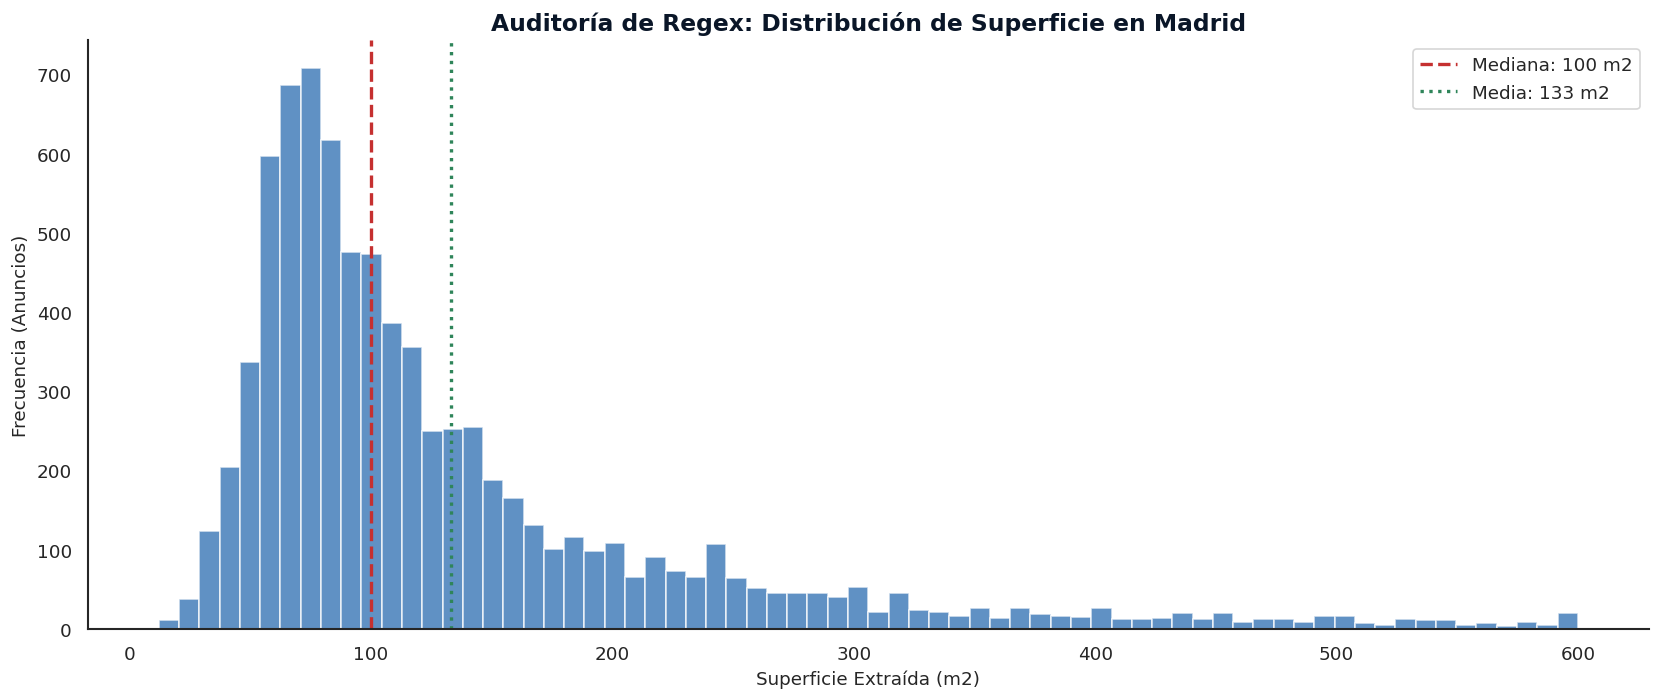

Validación superada. Mediana representativa: 100 m2


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

NAVY = '#0A1628'
GRIS = '#4A5568'
ROJO = '#C53030'
VERDE = '#2F855A'
AZUL = '#2B6CB0'

sns.set_theme(style='white', palette=[AZUL, GRIS, ROJO])
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

df_v = pd.read_csv(f'{BASE_DIR}/02_Datos_Procesados/pisos_procesados_gemini.csv')

fig, ax = plt.subplots(figsize=(14,6))
sup = df_v['superficie_m2'].dropna()
sup = sup[(sup >= 10) & (sup <= 600)]

ax.hist(sup, bins=70, color=AZUL, alpha=0.75, edgecolor='white')
ax.axvline(sup.median(), color=ROJO, ls='--', lw=2, label=f'Mediana: {sup.median():.0f} m2')
ax.axvline(sup.mean(), color=VERDE, ls=':', lw=2, label=f'Media: {sup.mean():.0f} m2')

ax.set_xlabel('Superficie Extraída (m2)', fontsize=11)
ax.set_ylabel('Frecuencia (Anuncios)', fontsize=11)
ax.set_title('Auditoría de Regex: Distribución de Superficie en Madrid', fontweight='bold', color=NAVY, fontsize=14)
ax.legend()

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/01_Datos_Crudos/val_superficie.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Validación superada. Mediana representativa: {sup.median():.0f} m2')

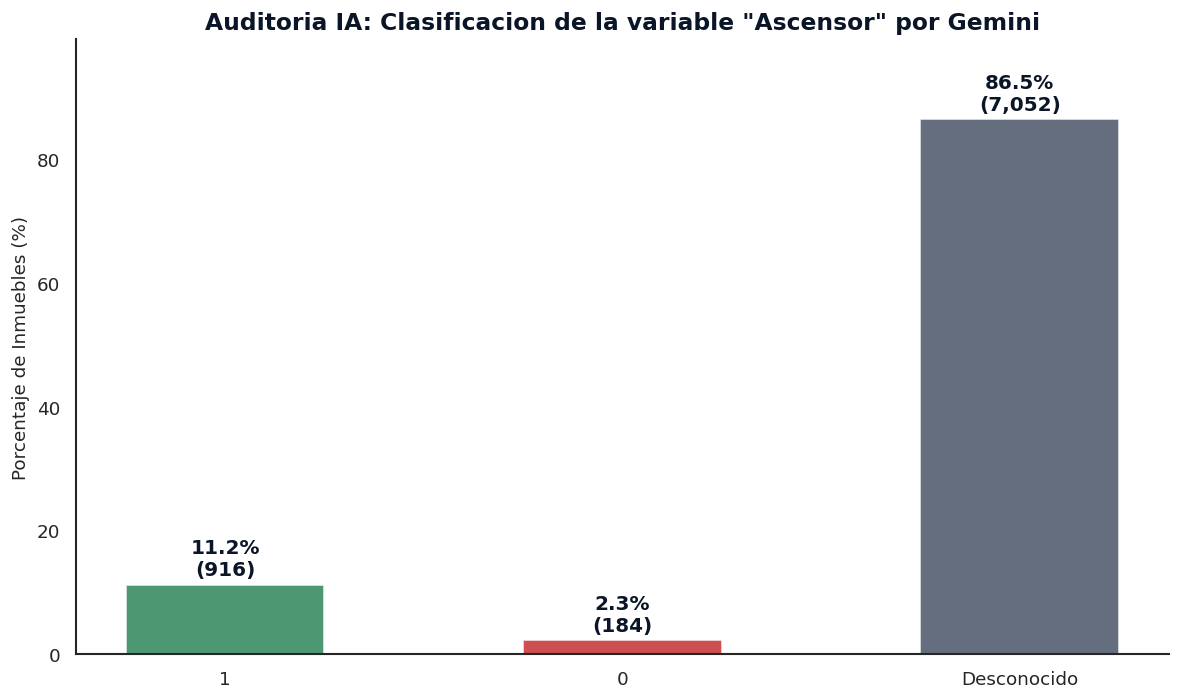

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

if 'ascensor' in df_v.columns:
    c = df_v['ascensor'].astype(str).value_counts()
    total = c.sum()
    cats, cols = ['1', '0', 'Desconocido'], [VERDE, ROJO, GRIS]
    vals = [c.get(x, 0) for x in cats]
    pcts = [v/total*100 for v in vals]

    bars = ax.bar(cats, pcts, color=cols, edgecolor='white', alpha=0.85, width=0.5)

    for b, pct, v in zip(bars, pcts, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5, f'{pct:.1f}%\n({v:,})',
                ha='center', fontweight='bold', color=NAVY)

    ax.set_ylabel('Porcentaje de Inmuebles (%)', fontsize=11)
    ax.set_title('Auditoria IA: Clasificacion de la variable "Ascensor" por Gemini', fontweight='bold', color=NAVY, fontsize=14)
    ax.set_ylim(0, max(pcts) * 1.15)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/01_Datos_Crudos/val_gemini.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Conclusiones de la ingesta y extracción de datos**

Tras finalizar este extenso proceso de recopilación, he logrado consolidar un conjunto de datos robusto de más de 8.100 registros. A pesar de los desafíos técnicos iniciales, como los bloqueos de los servidores y los límites de tasa de las herramientas gratuitas, la inversión en una infraestructura más sólida ha dado sus frutos. La estrategia de descarga de imágenes trazables ha sido un éxito rotundo, alcanzando una tasa de efectividad superior al 99%.

Sin embargo, la auditoría visual de los datos extraídos por la Inteligencia Artificial ha revelado una oportunidad de mejora crítica. Al delegar la obtención de la descripción a la cascada de extracción, el sistema ha priorizado las etiquetas SEO, las cuales carecen del nivel de detalle necesario para clasificar características específicas como el ascensor o la terraza. Esto ha provocado un alto volumen de valores "Desconocido", protegiendo el modelo de invenciones, pero limitando su alcance analítico. El siguiente paso técnico es reestructurar el orden de prioridad en la extracción de texto para alimentar al modelo generativo con descripciones completas, garantizando así un dataset impecable antes de iniciar la fase de modelado.

In [ ]:
# ── Antidesconexión de Colab ──────────────────────────────────────
# Ejecutar esta celda antes de cualquier proceso largo.
# Simula actividad cada 60 segundos para evitar que la sesión expire.
import IPython
display(IPython.display.Javascript('''
function ClickConnect(){
    console.log("Colab activo - " + new Date().toLocaleTimeString());
    document.querySelector("colab-connect-button").click();
}
setInterval(ClickConnect, 60000);
'''))
print("Antidesconexión activa. Colab se mantendrá vivo automáticamente.")



## **6. Re-scraping profundo de descripciones truncadas (Corrección de Nivel 1)**

El análisis post-ejecución reveló que el 94,1% de las descripciones (7.667 registros)
quedaron truncadas con "..." porque el Nivel 1 de la cascada (meta tags SEO)
devolvía el snippet corto de ~294 chars antes de llegar a los selectores CSS
con el texto completo del anuncio. Esta celda corrige ese problema sin borrar
nada: re-scrapea únicamente las URLs afectadas saltando el Nivel 1,
actualiza solo el campo descripcion en el CSV existente y deja intacto
todo lo demás.

In [ ]:
!pip install -q fake-useragent

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 4.0 MB/s eta 0:00:00


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re, json, time, random, os
from fake_useragent import UserAgent
from tqdm.notebook import tqdm

if 'BASE_DIR' not in globals():
    BASE_DIR = '/content/drive/MyDrive/TFM_VALORALIA_3'

ua = UserAgent()

# ── Cargamos el CSV existente ──────────────────────────────────────────────────
ruta_gemini = f'{BASE_DIR}/02_Datos_Procesados/pisos_procesados_gemini.csv'
df = pd.read_csv(ruta_gemini)
print(f'CSV cargado: {len(df)} filas')

# ── Identificamos solo las truncadas ──────────────────────────────────────────
mask_truncadas = df['descripcion'].astype(str).str.endswith('...')
print(f'Descripciones truncadas a re-scrapear: {mask_truncadas.sum()}')
print(f'Descripciones completas (intactas):     {(~mask_truncadas).sum()}')

# ── Función de scraping PROFUNDO: salta Nivel 1, va directo a CSS/JSON-LD ─────
def _limpiar_boilerplate(texto):
    if not texto:
        return ''
    texto = re.sub(r'^[Aa]ccede a la vista 3[Dd][^.]*\.\s*', '', texto)
    return texto

def extraer_descripcion_profunda(url):
    """
    Igual que la cascada original pero SIN Nivel 1 (meta tags).
    Meta tags son los que devuelven el snippet corto truncado.
    Va directo a selectores CSS → JSON-LD → párrafo más largo.
    """
    try:
        session = requests.Session()
        session.headers.update({
            'User-Agent': ua.random,
            'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
            'Accept-Language': 'es-ES,es;q=0.9',
        })
        r = session.get(url, timeout=25)
        if r.status_code != 200:
            return None
        soup = BeautifulSoup(r.text, 'lxml')

        # NIVEL 2: SELECTORES CSS (el texto largo real del anuncio)
        for selector in ['.description', '#description', '[class*="descrip"]',
                         '.js-description', '.p-desc', '[itemprop="description"]',
                         '.detail-description', '.comment', '[class*="comment"]',
                         '[class*="detail"]', '[class*="body"]']:
            el = soup.select_one(selector)
            if el:
                texto = _limpiar_boilerplate(el.get_text(strip=True))
                if len(texto) > 100 and not texto.endswith('...'):
                    return texto[:3000]

        # NIVEL 3: JSON-LD
        for script in soup.find_all('script', type='application/ld+json'):
            try:
                ld = json.loads(script.string)
                if isinstance(ld, list):
                    ld = ld[0]
                if isinstance(ld, dict) and 'description' in ld:
                    texto = _limpiar_boilerplate(str(ld['description']))
                    if len(texto) > 100 and not texto.endswith('...'):
                        return texto[:3000]
            except Exception:
                continue

        # NIVEL 4: PÁRRAFO MÁS LARGO (último recurso)
        mejor = ''
        for tag in soup.find_all(['p', 'div', 'span']):
            texto = _limpiar_boilerplate(tag.get_text(strip=True))
            if (len(texto) > len(mejor) and len(texto) > 150
                    and not texto.endswith('...')
                    and not any(x in texto.lower()[:30] for x in
                                ['cookie', 'copyr', 'aviso', 'política'])):
                mejor = texto
        if len(mejor) > 100:
            return mejor[:3000]

        return None  # No encontramos nada mejor → conservamos la original

    except Exception:
        return None

# ── Bucle de re-scraping ───────────────────────────────────────────────────────
indices_truncados = df[mask_truncadas].index.tolist()
mejoradas = 0
fallidas = 0

ruta_ckpt_rescrape = f'{BASE_DIR}/02_Datos_Procesados/_ckpt_rescrape_desc.csv'

# Retomar si ya habíamos empezado
if os.path.exists(ruta_ckpt_rescrape):
    df = pd.read_csv(ruta_ckpt_rescrape)
    # Recalcular cuántas siguen truncadas
    mask_pendientes = df['descripcion'].astype(str).str.endswith('...')
    indices_truncados = df[mask_pendientes].index.tolist()
    print(f'Retomando. Pendientes aún: {len(indices_truncados)}')

print(f'\nIniciando re-scraping de {len(indices_truncados)} URLs...')
print('(Solo se actualiza descripcion, todo lo demás permanece intacto)\n')

for i, idx in enumerate(tqdm(indices_truncados, desc='Re-scraping profundo')):
    url = df.at[idx, 'url']
    nueva_desc = extraer_descripcion_profunda(url)

    if nueva_desc and len(nueva_desc) > len(str(df.at[idx, 'descripcion'])):
        df.at[idx, 'descripcion'] = nueva_desc
        mejoradas += 1
    else:
        fallidas += 1

    time.sleep(random.uniform(1.5, 3.5))

    if (i + 1) % 100 == 0:
        df.to_csv(ruta_ckpt_rescrape, index=False)
        pct = mejoradas / (i + 1) * 100
        print(f'  Ckpt {i+1}/{len(indices_truncados)} | Mejoradas: {mejoradas} ({pct:.1f}%)')

df.to_csv(ruta_ckpt_rescrape, index=False)

desc_len_post = df['descripcion'].astype(str).str.len()
truncadas_post = df['descripcion'].astype(str).str.endswith('...')
print(f'\n{"="*60}')
print(f'RE-SCRAPING COMPLETADO')
print(f'{"="*60}')
print(f'  Descripciones mejoradas:     {mejoradas}')
print(f'  Sin mejora (conservan orig): {fallidas}')
print(f'  Longitud media post:         {desc_len_post.mean():.0f} chars')
print(f'  Aún truncadas:               {truncadas_post.sum()}')

CSV cargado: 8152 filas
Descripciones truncadas a re-scrapear: 7667
Descripciones completas (intactas):     485

Iniciando re-scraping de 7667 URLs...
(Solo se actualiza descripcion, todo lo demás permanece intacto)



Re-scraping profundo:   0%|          | 0/7667 [00:00<?, ?it/s]

  Ckpt 100/7667 | Mejoradas: 100 (100.0%)
  Ckpt 200/7667 | Mejoradas: 200 (100.0%)
  Ckpt 300/7667 | Mejoradas: 300 (100.0%)
  Ckpt 400/7667 | Mejoradas: 400 (100.0%)
  Ckpt 500/7667 | Mejoradas: 500 (100.0%)
  Ckpt 600/7667 | Mejoradas: 600 (100.0%)
  Ckpt 700/7667 | Mejoradas: 700 (100.0%)
  Ckpt 800/7667 | Mejoradas: 800 (100.0%)
  Ckpt 900/7667 | Mejoradas: 900 (100.0%)
  Ckpt 1000/7667 | Mejoradas: 1000 (100.0%)
  Ckpt 1100/7667 | Mejoradas: 1100 (100.0%)
  Ckpt 1200/7667 | Mejoradas: 1200 (100.0%)
  Ckpt 1300/7667 | Mejoradas: 1300 (100.0%)
  Ckpt 1400/7667 | Mejoradas: 1400 (100.0%)
  Ckpt 1500/7667 | Mejoradas: 1500 (100.0%)
  Ckpt 1600/7667 | Mejoradas: 1600 (100.0%)
  Ckpt 1700/7667 | Mejoradas: 1699 (99.9%)
  Ckpt 1800/7667 | Mejoradas: 1799 (99.9%)
  Ckpt 1900/7667 | Mejoradas: 1899 (99.9%)
  Ckpt 2000/7667 | Mejoradas: 1999 (100.0%)
  Ckpt 2100/7667 | Mejoradas: 2099 (100.0%)
  Ckpt 2200/7667 | Mejoradas: 2199 (100.0%)
  Ckpt 2300/7667 | Mejoradas: 2299 (100.0%)
  Ckpt 24

In [ ]:
# ── Antidesconexión de Colab ──────────────────────────────────────
# Ejecutar esta celda antes de cualquier proceso largo.
# Simula actividad cada 60 segundos para evitar que la sesión expire.
import IPython
display(IPython.display.Javascript('''
function ClickConnect(){
    console.log("Colab activo - " + new Date().toLocaleTimeString());
    document.querySelector("colab-connect-button").click();
}
setInterval(ClickConnect, 60000);
'''))
print("Antidesconexión activa. Colab se mantendrá vivo automáticamente.")

<IPython.core.display.Javascript object>

Antidesconexión activa. Colab se mantendrá vivo automáticamente.


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re, json, time, random, os
from fake_useragent import UserAgent
from tqdm.notebook import tqdm

if 'BASE_DIR' not in globals():
    BASE_DIR = '/content/drive/MyDrive/TFM_VALORALIA_3'

ua = UserAgent()
MIN_FOTOS = 4

# ── Cargamos el CSV existente ──────────────────────────────────────
ruta_gemini      = f'{BASE_DIR}/02_Datos_Procesados/pisos_procesados_gemini.csv'
ruta_ckpt_rescrape = f'{BASE_DIR}/02_Datos_Procesados/_ckpt_rescrape_desc.csv'

df = pd.read_csv(ruta_gemini)
print(f'CSV cargado: {len(df)} filas')

# ── Identificamos solo las truncadas ──────────────────────────────
mask_truncadas = df['descripcion'].astype(str).str.endswith('...')
print(f'Descripciones truncadas a re-scrapear: {mask_truncadas.sum()}')
print(f'Descripciones completas (intactas):     {(~mask_truncadas).sum()}')

# ── Función limpieza boilerplate ───────────────────────────────────
def _limpiar_boilerplate(texto):
    if not texto:
        return ''
    texto = re.sub(r'^[Aa]ccede a la vista 3[Dd][^.]*\.\s*', '', texto)
    return texto

# ── Función scraping profundo de descripciones (sin Nivel 1) ──────
def extraer_descripcion_profunda(url):
    try:
        session = requests.Session()
        session.headers.update({
            'User-Agent': ua.random,
            'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
            'Accept-Language': 'es-ES,es;q=0.9',
        })
        r = session.get(url, timeout=25)
        if r.status_code != 200:
            return None
        soup = BeautifulSoup(r.text, 'lxml')

        # NIVEL 2: SELECTORES CSS
        for selector in ['.description', '#description', '[class*="descrip"]',
                         '.js-description', '.p-desc', '[itemprop="description"]',
                         '.detail-description', '.comment', '[class*="comment"]',
                         '[class*="detail"]', '[class*="body"]']:
            el = soup.select_one(selector)
            if el:
                texto = _limpiar_boilerplate(el.get_text(strip=True))
                if len(texto) > 100 and not texto.endswith('...'):
                    return texto[:3000]

        # NIVEL 3: JSON-LD
        for script in soup.find_all('script', type='application/ld+json'):
            try:
                ld = json.loads(script.string)
                if isinstance(ld, list):
                    ld = ld[0]
                if isinstance(ld, dict) and 'description' in ld:
                    texto = _limpiar_boilerplate(str(ld['description']))
                    if len(texto) > 100 and not texto.endswith('...'):
                        return texto[:3000]
            except Exception:
                continue

        # NIVEL 4: PÁRRAFO MÁS LARGO
        mejor = ''
        for tag in soup.find_all(['p', 'div', 'span']):
            texto = _limpiar_boilerplate(tag.get_text(strip=True))
            if (len(texto) > len(mejor) and len(texto) > 150
                    and not texto.endswith('...')
                    and not any(x in texto.lower()[:30] for x in
                                ['cookie', 'copyr', 'aviso', 'política'])):
                mejor = texto
        if len(mejor) > 100:
            return mejor[:3000]

        return None

    except Exception:
        return None

# ── Función limpieza URLs duplicadas de imágenes ───────────────────
def limpiar_urls_imagenes(urls_str):
    if pd.isna(urls_str) or not str(urls_str).strip():
        return []
    urls = str(urls_str).split('|')
    por_numero = {}
    sin_numero = []
    for u in urls:
        u = u.strip()
        if not u or 'prof-wp' in u:
            continue
        m = re.search(r'_(\d+)_\d{10,}', u)
        if m:
            num = m.group(1)
            if num not in por_numero or 'xl-wp' in u:
                por_numero[num] = u
        else:
            sin_numero.append(u)
    ordenadas = [por_numero[k] for k in sorted(por_numero, key=lambda x: int(x))]
    return ordenadas + sin_numero

# ── Función re-scraping de imágenes ───────────────────────────────
def rescrape_imagenes(url_piso):
    try:
        session = requests.Session()
        session.headers.update({'User-Agent': ua.random,
                                'Accept-Language': 'es-ES,es;q=0.9'})
        r = session.get(url_piso, timeout=25)
        if r.status_code != 200:
            return []
        patron = r'https?://fotos\.imghs\.net/[^\s"\\<>]+?\.(?:jpg|jpeg|webp)'
        urls_raw = re.findall(patron, r.text, re.IGNORECASE)
        urls_raw = [u.replace('\\/', '/').replace('\\', '') for u in urls_raw]
        return limpiar_urls_imagenes('|'.join(urls_raw))
    except Exception:
        return []

# ══════════════════════════════════════════════════════════════════
# FASE A: RE-SCRAPING DE DESCRIPCIONES TRUNCADAS
# ══════════════════════════════════════════════════════════════════
indices_truncados = df[mask_truncadas].index.tolist()
mejoradas = 0
fallidas  = 0

if os.path.exists(ruta_ckpt_rescrape):
    df = pd.read_csv(ruta_ckpt_rescrape)
    mask_pendientes   = df['descripcion'].astype(str).str.endswith('...')
    indices_truncados = df[mask_pendientes].index.tolist()
    print(f'Retomando. Pendientes aún: {len(indices_truncados)}')

print(f'\nFASE A: Re-scraping de {len(indices_truncados)} descripciones truncadas...\n')

for i, idx in enumerate(tqdm(indices_truncados, desc='Re-scraping descripciones')):
    url       = df.at[idx, 'url']
    nueva_desc = extraer_descripcion_profunda(url)
    if nueva_desc and len(nueva_desc) > len(str(df.at[idx, 'descripcion'])):
        df.at[idx, 'descripcion'] = nueva_desc
        mejoradas += 1
    else:
        fallidas += 1
    time.sleep(random.uniform(1.5, 3.5))
    if (i + 1) % 100 == 0:
        df.to_csv(ruta_ckpt_rescrape, index=False)
        print(f'  Ckpt {i+1}/{len(indices_truncados)} | Mejoradas: {mejoradas} ({mejoradas/(i+1)*100:.1f}%)')

df.to_csv(ruta_ckpt_rescrape, index=False)
desc_len_post  = df['descripcion'].astype(str).str.len()
truncadas_post = df['descripcion'].astype(str).str.endswith('...')
print(f'\n{"="*60}')
print(f'FASE A COMPLETADA')
print(f'  Descripciones mejoradas:     {mejoradas}')
print(f'  Sin mejora (conservan orig): {fallidas}')
print(f'  Longitud media post:         {desc_len_post.mean():.0f} chars')
print(f'  Aún truncadas:               {truncadas_post.sum()}')

# ══════════════════════════════════════════════════════════════════
# FASE B: LIMPIEZA Y RESCATE DE IMÁGENES
# ══════════════════════════════════════════════════════════════════
print(f'\nFASE B: Limpiando URLs duplicadas de imágenes...')

df['_urls_limpias'] = df['urls_imagenes'].apply(limpiar_urls_imagenes)
df['_n_limpias']    = df['_urls_limpias'].apply(len)

print(f'  Antes  → num_imagenes media:  {df["num_imagenes"].mean():.1f}')
print(f'  Después → fotos reales media: {df["_n_limpias"].mean():.1f}')
print(f'  Pisos con < {MIN_FOTOS} fotos reales: {(df["_n_limpias"] < MIN_FOTOS).sum()}')

mask_pocas      = df['_n_limpias'] < MIN_FOTOS
indices_pocas   = df[mask_pocas].index.tolist()
rescatadas      = 0

print(f'\nRe-scrapeando imágenes de {len(indices_pocas)} pisos con < {MIN_FOTOS} fotos...')

for i, idx in enumerate(tqdm(indices_pocas, desc='Rescate de fotos')):
    nuevas = rescrape_imagenes(df.at[idx, 'url'])
    if len(nuevas) > df.at[idx, '_n_limpias']:
        df.at[idx, '_urls_limpias'] = nuevas
        df.at[idx, '_n_limpias']    = len(nuevas)
        rescatadas += 1
    time.sleep(random.uniform(1.0, 2.5))
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(indices_pocas)} | Mejoradas: {rescatadas}')

df['urls_imagenes']        = df['_urls_limpias'].apply(lambda x: '|'.join(x) if x else np.nan)
df['url_imagen_principal'] = df['_urls_limpias'].apply(lambda x: x[0] if x else np.nan)
df['num_imagenes']         = df['_n_limpias']
df.drop(columns=['_urls_limpias', '_n_limpias'], inplace=True)

df.to_csv(ruta_ckpt_rescrape, index=False)

print(f'\n{"="*60}')
print(f'FASE B COMPLETADA')
print(f'  Fotos rescatadas:                {rescatadas}')
print(f'  Fotos reales medias por piso:    {df["num_imagenes"].mean():.1f}')
print(f'  Pisos con >= {MIN_FOTOS} fotos:          {(df["num_imagenes"] >= MIN_FOTOS).sum()} ({(df["num_imagenes"] >= MIN_FOTOS).sum()/len(df)*100:.1f}%)')
print(f'  Pisos con 0 fotos:               {(df["num_imagenes"] == 0).sum()}')
print(f'\nCheckpoint actualizado: _ckpt_rescrape_desc.csv')

CSV cargado: 8152 filas
Descripciones truncadas a re-scrapear: 7667
Descripciones completas (intactas):     485
Retomando. Pendientes aún: 1

FASE A: Re-scraping de 1 descripciones truncadas...



Re-scraping descripciones:   0%|          | 0/1 [00:00<?, ?it/s]


FASE A COMPLETADA
  Descripciones mejoradas:     1
  Sin mejora (conservan orig): 0
  Longitud media post:         1566 chars
  Aún truncadas:               0

FASE B: Limpiando URLs duplicadas de imágenes...
  Antes  → num_imagenes media:  17.7
  Después → fotos reales media: 12.8
  Pisos con < 4 fotos reales: 886

Re-scrapeando imágenes de 886 pisos con < 4 fotos...


Rescate de fotos:   0%|          | 0/886 [00:00<?, ?it/s]

  50/886 | Mejoradas: 1
  100/886 | Mejoradas: 5
  150/886 | Mejoradas: 7
  200/886 | Mejoradas: 10
  250/886 | Mejoradas: 15
  300/886 | Mejoradas: 19
  350/886 | Mejoradas: 20
  400/886 | Mejoradas: 22
  450/886 | Mejoradas: 22
  500/886 | Mejoradas: 27
  550/886 | Mejoradas: 30
  600/886 | Mejoradas: 33
  650/886 | Mejoradas: 34
  700/886 | Mejoradas: 36
  750/886 | Mejoradas: 37
  800/886 | Mejoradas: 42
  850/886 | Mejoradas: 45

FASE B COMPLETADA
  Fotos rescatadas:                46
  Fotos reales medias por piso:    12.9
  Pisos con >= 4 fotos:          7299 (89.5%)
  Pisos con 0 fotos:               87

Checkpoint actualizado: _ckpt_rescrape_desc.csv


## **7. Re-extracción con Gemini sobre descripciones mejoradas**

Con las descripciones completas ya en el dataframe, volvemos a pasar por
Gemini **únicamente** los registros que (a) tienen descripción mejorada Y
(b) siguen con todas las variables Gemini en Desconocido.
Los registros que ya tenían alguna variable conocida no se tocan.

In [ ]:
# ── Antidesconexión de Colab ──────────────────────────────────────
# Ejecutar esta celda antes de cualquier proceso largo.
# Simula actividad cada 60 segundos para evitar que la sesión expire.
import IPython
display(IPython.display.Javascript('''
function ClickConnect(){
    console.log("Colab activo - " + new Date().toLocaleTimeString());
    document.querySelector("colab-connect-button").click();
}
setInterval(ClickConnect, 60000);
'''))
print("Antidesconexión activa. Colab se mantendrá vivo automáticamente.")

<IPython.core.display.Javascript object>

Antidesconexión activa. Colab se mantendrá vivo automáticamente.


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# RECONEXIÓN RÁPIDA — Ejecutar esto tras desconexión de Colab
# Reinstala, importa, monta Drive y activa antidesconexión de golpe
# ═══════════════════════════════════════════════════════════════════

!pip install -q beautifulsoup4 lxml Pillow tqdm fake-useragent

import requests, json, time, os, re, random, hashlib
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm
from PIL import Image
from io import BytesIO
from fake_useragent import UserAgent
import warnings
warnings.filterwarnings('ignore')
ua = UserAgent()

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/TFM_VALORALIA_3'
for sub in ['01_Datos_Crudos', '02_Datos_Procesados', '03_Imagenes_Multiples']:
    os.makedirs(f'{BASE_DIR}/{sub}', exist_ok=True)

# Antidesconexión
import IPython
display(IPython.display.Javascript('''
function ClickConnect(){
    console.log("Colab activo - " + new Date().toLocaleTimeString());
    document.querySelector("colab-connect-button").click();
}
setInterval(ClickConnect, 60000);
'''))

print(f'Entorno listo. Drive montado. BASE_DIR = {BASE_DIR}')
print(f'Antidesconexión activa.')
print(f'\nAhora ejecuta la celda de Gemini v2 (la siguiente). Retomará sola desde el checkpoint ~3500.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 3.9 MB/s eta 0:00:00
Mounted at /content/drive


<IPython.core.display.Javascript object>

Entorno listo. Drive montado. BASE_DIR = /content/drive/MyDrive/TFM_VALORALIA_3
Antidesconexión activa.

Ahora ejecuta la celda de Gemini v2 (la siguiente). Retomará sola desde el checkpoint ~3500.


**### Reconexión forzada tras desconexión de sesión (segunda pasada de Gemini)**

Esto merece un párrafo aparte porque refleja una de las realidades más frustrantes del trabajo con herramientas en la nube cuando no se dispone de infraestructura propia. La celda anterior (re-extracción con Gemini sobre las descripciones mejoradas) llevaba más de tres horas y media ejecutándose, había procesado 3.500 de los 4.102 registros pendientes — un 85% del trabajo — cuando Google Colab decidió cerrarme la sesión sin previo aviso.

No es la primera vez que ocurre, y a estas alturas del proyecto ya he perdido la cuenta de cuántas veces he tenido que reiniciar procesos largos por desconexiones inesperadas. Lo que más duele es que esto sucede incluso habiendo invertido dinero de mi propio bolsillo en la cuenta de facturación de Gemini para eliminar los límites de tasa, e incluso dejando el ordenador encendido toda la noche con el truco de antidesconexión keep-alive, que es un mecanismo que simula actividad periódica en el navegador para evitar que el servidor cierre la sesión por inactividad. Aun así, Colab tiene un límite máximo de duración de sesión que no respeta ni los scripts de mantenimiento ni el sentido común.

La única razón por la que no he perdido esas tres horas y media de ejecución es porque diseñé el código con puntos de control checkpoints cada 100 registros. El archivo pisos_procesados_gemini_v2.csv ya contiene los 3.500 registros procesados hasta el momento de la caída. En la celda siguiente vuelvo a cargar las librerías, montar Google Drive y activar la antidesconexión para retomar exactamente donde se cortó, sin repetir ni un solo registro. Es una lección que aprendí a base de perder trabajo: nunca ejecutar un proceso largo sin guardado incremental, porque la infraestructura gratuita (y la de pago, al parecer) no garantiza estabilidad. Otra noche que se quda el ordenador encendido.

In [ ]:
import json, time, requests, os
import pandas as pd
from tqdm.notebook import tqdm
from google.colab import userdata

if 'BASE_DIR' not in globals():
    BASE_DIR = '/content/drive/MyDrive/TFM_VALORALIA_3'

try:
    CLAVE_GEMINI = userdata.get('GEMINI_API_KEY')
except:
    CLAVE_GEMINI = globals().get('GEMINI_API_KEY', '')
if CLAVE_GEMINI:
    CLAVE_GEMINI = str(CLAVE_GEMINI).strip()

# ── Cargamos el CSV con descripciones ya mejoradas
ruta_ckpt_rescrape = f'{BASE_DIR}/02_Datos_Procesados/_ckpt_rescrape_desc.csv'
df = pd.read_csv(ruta_ckpt_rescrape)
print(f'CSV cargado: {len(df)} filas')

# ── Identificamos qué filas necesitan re-extracción Gemini
# Condición: descripción ya NO truncada Y todas las vars Gemini son Desconocido
vars_gemini = ['ascensor', 'terraza', 'garaje', 'calefaccion', 'estado_reforma']
todo_desconocido = df[vars_gemini].apply(lambda r: (r == 'Desconocido').all(), axis=1)
no_truncada = ~df['descripcion'].astype(str).str.endswith('...')
desc_larga = df['descripcion'].astype(str).str.len() > 200

mask_re_gemini = todo_desconocido & no_truncada & desc_larga
print(f'Filas a re-procesar con Gemini: {mask_re_gemini.sum()}')
print(f'Filas que NO se tocan (ya tenían datos o siguen truncadas): {(~mask_re_gemini).sum()}')

# ── Prompt y función Gemini (igual que NB01)
PROMPT_GEMINI = '''Lee esta descripcion inmobiliaria y devuelveme exclusivamente un JSON con estas 5 claves: ascensor, terraza, garaje, calefaccion, estado_reforma.
Reglas:
- Si el texto afirma explicitamente que lo tiene, pon 1.
- Si el texto afirma explicitamente que NO lo tiene, pon 0.
- Si el texto no menciona nada sobre ese elemento, pon "Desconocido".
- NO deduzcas ni inventes datos.
- Devuelve SOLO el JSON, sin texto adicional ni backticks.
Descripcion:
{texto}'''

MODELOS = ["gemini-2.5-flash", "gemini-2.0-flash", "gemini-1.5-flash"]
modelo_activo = None

def extraer_variables_gemini(texto):
    global modelo_activo
    default = {k: 'Desconocido' for k in vars_gemini}
    if not texto or pd.isna(texto) or len(str(texto)) < 50:
        return default
    payload = {"contents": [{"parts": [{"text": PROMPT_GEMINI.format(texto=str(texto)[:2000])}]}]}
    headers = {'Content-Type': 'application/json'}
    modelos_a_probar = [modelo_activo] if modelo_activo else MODELOS
    for modelo in modelos_a_probar:
        url = f"https://generativelanguage.googleapis.com/v1beta/models/{modelo}:generateContent?key={CLAVE_GEMINI}"
        try:
            r = requests.post(url, json=payload, headers=headers, timeout=30)
            if r.status_code == 200:
                if not modelo_activo:
                    print(f'\n  [INFO] Modelo activo: {modelo}')
                    modelo_activo = modelo
                txt = r.json()['candidates'][0]['content']['parts'][0]['text']
                txt = txt.strip().replace('```json', '').replace('```', '')
                datos = json.loads(txt)
                for k in default:
                    if k not in datos:
                        datos[k] = 'Desconocido'
                return datos
            elif r.status_code == 429:
                time.sleep(5)
                continue
        except Exception:
            continue
    return default

# ── Bucle de re-extracción
indices = df[mask_re_gemini].index.tolist()
actualizadas = 0

ruta_final_v2 = f'{BASE_DIR}/02_Datos_Procesados/pisos_procesados_gemini_v2.csv'

# Retomar si existe checkpoint
if os.path.exists(ruta_final_v2):
    df_check = pd.read_csv(ruta_final_v2)
    # Ver cuáles ya no son todo desconocido en v2
    ya_procesados = df_check[vars_gemini].apply(
        lambda r: not (r == 'Desconocido').all(), axis=1)
    indices = [i for i in indices if not ya_procesados.iloc[i]]
    df = df_check.copy()
    print(f'Retomando. Pendientes: {len(indices)}')

print(f'\nRe-extrayendo {len(indices)} registros con Gemini...\n')

for i, idx in enumerate(tqdm(indices, desc='Gemini v2')):
    resultado = extraer_variables_gemini(df.at[idx, 'descripcion'])
    for clave, valor in resultado.items():
        df.at[idx, clave] = valor
    if not all(v == 'Desconocido' for v in resultado.values()):
        actualizadas += 1

    time.sleep(0.05)

    if (i + 1) % 100 == 0:
        df.to_csv(ruta_final_v2, index=False)
        print(f'  Ckpt {i+1}/{len(indices)} | Con algún dato: {actualizadas}')

# ── Guardar CSV final v2
df.to_csv(ruta_final_v2, index=False, encoding='utf-8-sig')

print(f'\n{"="*60}')
print(f'GEMINI V2 COMPLETADO')
print(f'{"="*60}')
for col in vars_gemini:
    c = df[col].value_counts(dropna=False)
    total = len(df)
    desc = c.get('Desconocido', 0)
    uno  = c.get(1, c.get('1', 0))
    cero = c.get(0, c.get('0', 0))
    print(f'\n  {col}:')
    print(f'    1 (tiene):       {uno:>5} ({uno/total*100:.1f}%)')
    print(f'    0 (no tiene):    {cero:>5} ({cero/total*100:.1f}%)')
    print(f'    Desconocido:     {desc:>5} ({desc/total*100:.1f}%)')

print(f'\nCSV final guardado en: pisos_procesados_gemini_v2.csv')
print('En NB02 usa este archivo en lugar del anterior.')

CSV cargado: 8152 filas
Filas a re-procesar con Gemini: 4102
Filas que NO se tocan (ya tenían datos o siguen truncadas): 4050
Retomando. Pendientes: 1526

Re-extrayendo 1526 registros con Gemini...



Gemini v2:   0%|          | 0/1526 [00:00<?, ?it/s]


  [INFO] Modelo activo: gemini-2.5-flash
  Ckpt 100/1526 | Con algún dato: 4
  Ckpt 200/1526 | Con algún dato: 7
  Ckpt 300/1526 | Con algún dato: 10
  Ckpt 400/1526 | Con algún dato: 13
  Ckpt 500/1526 | Con algún dato: 15
  Ckpt 600/1526 | Con algún dato: 19
  Ckpt 700/1526 | Con algún dato: 23
  Ckpt 800/1526 | Con algún dato: 28
  Ckpt 900/1526 | Con algún dato: 30
  Ckpt 1000/1526 | Con algún dato: 82
  Ckpt 1100/1526 | Con algún dato: 156
  Ckpt 1200/1526 | Con algún dato: 245
  Ckpt 1300/1526 | Con algún dato: 335
  Ckpt 1400/1526 | Con algún dato: 426
  Ckpt 1500/1526 | Con algún dato: 497

GEMINI V2 COMPLETADO

  ascensor:
    1 (tiene):          56 (0.7%)
    0 (no tiene):       14 (0.2%)
    Desconocido:      5880 (72.1%)

  terraza:
    1 (tiene):         284 (3.5%)
    0 (no tiene):        2 (0.0%)
    Desconocido:      5751 (70.5%)

  garaje:
    1 (tiene):         343 (4.2%)
    0 (no tiene):        1 (0.0%)
    Desconocido:      6346 (77.8%)

  calefaccion:
    1 (tien

## 8. Limpieza y rescate de imágenes duplicadas

Al revisar el campo urls_imagenes he detectado un error crítico en mi
scraper original: por cada foto real del piso se guardaban hasta 4 URLs
distintas apuntando al mismo archivo físico pero con prefijos de tamaño
diferentes (xl-wp, fch-wp, fchm-wp, apps-wp...). Además, el logo
de la agencia inmobiliaria (prof-wp) se colaba contando como una foto más
del inmueble. El resultado es que `num_imagenes` marcaba hasta 20 cuando en
realidad muchos pisos tienen 0, 1 o 2 fotos reales únicas, muy por debajo
del mínimo necesario para que ResNet50 genere embeddings visuales fiables
en NB03.

Esta celda corrige los dos problemas sin tocar nada de lo anterior:
1. Deduplica las URLs conservando una sola por foto real (la de mayor resolución, prefijo xl-wp).
2. Descarta los logos de agencia prof-wp.
3. Identifica los pisos que tras la limpieza tienen menos de 4 fotos reales y re-scrapea sus URLs desde la web.
4. Actualiza urls_imagenes, `url_imagen_principal y num_imagenes en el dataframe ya en memoria.


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELDA 8: Limpieza de URLs duplicadas + rescate de fotos insuficientes
# Continúa sobre el df ya en memoria de la celda anterior
# ═══════════════════════════════════════════════════════════════════

MIN_FOTOS = 4  # mínimo de fotos reales únicas que exigimos por piso

# ── Función: extrae foto única real por número, descarta logos ──────
def limpiar_urls_imagenes(urls_str):
    """
    De todas las URLs guarda una sola por número de foto (la xl-wp si existe,
    si no la primera que aparezca). Descarta logos de agencia (prof-wp).
    Devuelve lista de URLs limpias.
    """
    if pd.isna(urls_str) or not str(urls_str).strip():
        return []
    urls = str(urls_str).split('|')
    por_numero = {}
    sin_numero = []
    for u in urls:
        u = u.strip()
        if not u or 'prof-wp' in u:          # descarta logos
            continue
        m = re.search(r'_(\d+)_\d{10,}', u)
        if m:
            num = m.group(1)
            # Preferimos xl-wp (mayor resolución), luego la primera que llegue
            if num not in por_numero or 'xl-wp' in u:
                por_numero[num] = u
        else:
            sin_numero.append(u)
    # Ordenamos por número de foto
    ordenadas = [por_numero[k] for k in sorted(por_numero, key=lambda x: int(x))]
    return ordenadas + sin_numero

# ── Aplicamos limpieza a todo el df
print('Limpiando URLs duplicadas en todo el dataset...')
df['_urls_limpias'] = df['urls_imagenes'].apply(limpiar_urls_imagenes)
df['_n_limpias']    = df['_urls_limpias'].apply(len)

print(f'  Antes  → num_imagenes media: {df["num_imagenes"].mean():.1f}')
print(f'  Después → fotos reales media: {df["_n_limpias"].mean():.1f}')
print(f'  Pisos con < {MIN_FOTOS} fotos reales: {(df["_n_limpias"] < MIN_FOTOS).sum()}')
print(f'  Pisos con 0 fotos reales:    {(df["_n_limpias"] == 0).sum()}')

# ── Función: re-scrapea URLs de imágenes para un piso concreto
def rescrape_imagenes(url_piso):
    """
    Entra en la URL del piso y extrae URLs de fotos únicas reales
    directamente del HTML crudo (mismo método que Regla 3 del NB01).
    """
    try:
        session = requests.Session()
        session.headers.update({'User-Agent': ua.random,
                                'Accept-Language': 'es-ES,es;q=0.9'})
        r = session.get(url_piso, timeout=25)
        if r.status_code != 200:
            return []
        patron = r'https?://fotos\.imghs\.net/[^\s"\\<>]+?\.(?:jpg|jpeg|webp)'
        urls_raw = re.findall(patron, r.text, re.IGNORECASE)
        urls_raw = [u.replace('\\/', '/').replace('\\', '') for u in urls_raw]
        return limpiar_urls_imagenes('|'.join(urls_raw))
    except Exception:
        return []

# ── Re-scraping solo para pisos con < MIN_FOTOS fotos reales
mask_pocas = df['_n_limpias'] < MIN_FOTOS
indices_pocas = df[mask_pocas].index.tolist()
print(f'\nRe-scrapeando imágenes de {len(indices_pocas)} pisos con < {MIN_FOTOS} fotos...')

rescatadas = 0
for i, idx in enumerate(tqdm(indices_pocas, desc='Rescate de fotos')):
    nuevas = rescrape_imagenes(df.at[idx, 'url'])
    if len(nuevas) > df.at[idx, '_n_limpias']:
        df.at[idx, '_urls_limpias'] = nuevas
        df.at[idx, '_n_limpias']    = len(nuevas)
        rescatadas += 1
    time.sleep(random.uniform(1.0, 2.5))
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(indices_pocas)} | Mejoradas: {rescatadas}')

# ── Escribimos las columnas definitivas en el df
df['urls_imagenes']        = df['_urls_limpias'].apply(lambda x: '|'.join(x) if x else np.nan)
df['url_imagen_principal'] = df['_urls_limpias'].apply(lambda x: x[0] if x else np.nan)
df['num_imagenes']         = df['_n_limpias']
df.drop(columns=['_urls_limpias', '_n_limpias'], inplace=True)

# ── Guardamos sobre el mismo checkpoint del re-scraping
df.to_csv(ruta_ckpt_rescrape, index=False)

print(f'\n{"="*60}')
print(f'LIMPIEZA DE IMÁGENES COMPLETADA')
print(f'{"="*60}')
print(f'  Pisos con imagen rescatada:      {rescatadas}')
print(f'  Fotos reales medias por piso:    {df["num_imagenes"].mean():.1f}')
print(f'  Pisos con >= {MIN_FOTOS} fotos:         {(df["num_imagenes"] >= MIN_FOTOS).sum()} ({(df["num_imagenes"] >= MIN_FOTOS).sum()/len(df)*100:.1f}%)')
print(f'  Pisos con 0 fotos (irrecuperables): {(df["num_imagenes"] == 0).sum()}')
print(f'\nCSV actualizado en: _ckpt_rescrape_desc.csv')

Limpiando URLs duplicadas en todo el dataset...
  Antes  → num_imagenes media: 17.7
  Después → fotos reales media: 12.8
  Pisos con < 4 fotos reales: 886
  Pisos con 0 fotos reales:    89

Re-scrapeando imágenes de 886 pisos con < 4 fotos...


Rescate de fotos:   0%|          | 0/886 [00:00<?, ?it/s]

  50/886 | Mejoradas: 2
  100/886 | Mejoradas: 6
  150/886 | Mejoradas: 8
  200/886 | Mejoradas: 11
  250/886 | Mejoradas: 16
  300/886 | Mejoradas: 20
  350/886 | Mejoradas: 22
  400/886 | Mejoradas: 24
  450/886 | Mejoradas: 24
  500/886 | Mejoradas: 29
  550/886 | Mejoradas: 32
  600/886 | Mejoradas: 35
  650/886 | Mejoradas: 37
  700/886 | Mejoradas: 40
  750/886 | Mejoradas: 41
  800/886 | Mejoradas: 46
  850/886 | Mejoradas: 49

LIMPIEZA DE IMÁGENES COMPLETADA
  Pisos con imagen rescatada:      50
  Fotos reales medias por piso:    12.9
  Pisos con >= 4 fotos:         7303 (89.6%)
  Pisos con 0 fotos (irrecuperables): 87

CSV actualizado en: _ckpt_rescrape_desc.csv


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CELDA 9: Rescate analítico de variables desde texto (sin inventar)
# Lee pisos_procesados_gemini_v2.csv y genera pisos_procesados_salvados.csv
# ═══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import re

if 'BASE_DIR' not in globals():
    BASE_DIR = '/content/drive/MyDrive/TFM_VALORALIA_3'

ruta_v2      = f'{BASE_DIR}/02_Datos_Procesados/pisos_procesados_gemini_v2.csv'
ruta_salvado = f'{BASE_DIR}/02_Datos_Procesados/pisos_procesados_salvados.csv'

df_rescate = pd.read_csv(ruta_v2)
print(f'CSV cargado: {len(df_rescate)} filas')

def rescatar_variables(row):
    texto_total = str(row['titulo']).lower() + " " + str(row['descripcion']).lower()

    # ── Ascensor ── NEGACIONES PRIMERO para que "sin ascensor" no se cuele como 1
    if row['ascensor'] == 'Desconocido':
        if re.search(r'sin\s+ascensor|no\s+(?:tiene|dispone|hay)\s+ascensor|no\s+ascensor|carece\s+de\s+ascensor', texto_total):
            row['ascensor'] = '0'
        elif re.search(r'\bascensor\b|\belevador\b|\bcon\s+ascensor\b', texto_total):
            row['ascensor'] = '1'

    # ── Terraza ── NEGACIONES PRIMERO
    if row['terraza'] == 'Desconocido':
        if re.search(r'sin\s+terraza|no\s+(?:tiene|dispone|hay)\s+terraza|sin\s+balc[oó]n', texto_total):
            row['terraza'] = '0'
        elif re.search(r'\bterraza\b|\bbalc[oó]n\b|\bpatio\b|\bjard[ií]n\b|\bsolarium\b', texto_total):
            row['terraza'] = '1'

    # ── Garaje ── NEGACIONES PRIMERO
    if row['garaje'] == 'Desconocido':
        if re.search(r'sin\s+(?:garaje|parking|plaza\s+de\s+garaje)|no\s+(?:tiene|dispone|incluye)\s+(?:garaje|parking|aparcamiento)', texto_total):
            row['garaje'] = '0'
        elif re.search(r'\bgaraje\b|\bparking\b|\baparcamiento\b|\bplaza\s+de\s+garaje\b|\bcochera\b', texto_total):
            row['garaje'] = '1'

    # ── Calefacción ── NEGACIONES PRIMERO
    if row['calefaccion'] == 'Desconocido':
        if re.search(r'sin\s+calefacci[oó]n|no\s+(?:tiene|dispone|hay)\s+calefacci[oó]n', texto_total):
            row['calefaccion'] = '0'
        elif re.search(r'calefacci[oó]n|climatizaci[oó]n|radiador|caldera|suelo\s+radiante|bomba\s+de\s+calor|aerotermia', texto_total):
            row['calefaccion'] = '1'

    # ── Estado reforma ── NEGACIONES PRIMERO
    if row['estado_reforma'] == 'Desconocido':
        if re.search(r'a\s+reformar|para\s+reformar|necesita\s+reforma|estado\s+original|pendiente\s+de\s+reforma', texto_total):
            row['estado_reforma'] = '0'
        elif re.search(r'reformad[oa]|a\s+estrenar|obra\s+nueva|impecable|reci[eé]n\s+reformad|totalmente\s+reformad|reform[oa]\s+integral', texto_total):
            row['estado_reforma'] = '1'

    return row

print("Iniciando rescate analítico desde títulos y descripciones...")
print("(Negaciones ANTES que positivos — 'sin ascensor' → 0, no 1)")

df_salvado = df_rescate.apply(rescatar_variables, axis=1)

print("\nResultados del rescate (solo texto, cero inferencias por tipo):")
for col in ['ascensor', 'terraza', 'garaje', 'calefaccion', 'estado_reforma']:
    prev  = (df_rescate[col] == 'Desconocido').sum()
    post  = (df_salvado[col]  == 'Desconocido').sum()
    recup = prev - post
    # Desglose de lo rescatado
    nuevos_1 = ((df_rescate[col] == 'Desconocido') & (df_salvado[col] == '1')).sum()
    nuevos_0 = ((df_rescate[col] == 'Desconocido') & (df_salvado[col] == '0')).sum()
    print(f"  {col:18s}: +{recup:>4d} rescatados (→1: {nuevos_1}, →0: {nuevos_0}) | Desconocido restante: {post}")

df_salvado.to_csv(ruta_salvado, index=False, encoding='utf-8-sig')
print(f"\nCSV final guardado: pisos_procesados_salvados.csv")
print("Este es el archivo que carga NB02.")

CSV cargado: 8152 filas
Iniciando rescate analítico desde títulos y descripciones...
(Negaciones ANTES que positivos — 'sin ascensor' → 0, no 1)

Resultados del rescate (solo texto, cero inferencias por tipo):
  ascensor          : + 776 rescatados (→1: 716, →0: 60) | Desconocido restante: 5104
  terraza           : +1784 rescatados (→1: 1784, →0: 0) | Desconocido restante: 3967
  garaje            : + 990 rescatados (→1: 987, →0: 3) | Desconocido restante: 5356
  calefaccion       : +1780 rescatados (→1: 1780, →0: 0) | Desconocido restante: 4584
  estado_reforma    : + 742 rescatados (→1: 662, →0: 80) | Desconocido restante: 4005

CSV final guardado: pisos_procesados_salvados.csv
Este es el archivo que carga NB02.


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# PARCHE: Limpiar URLs en pisos_procesados_salvados.csv
# antes de la descarga definitiva de imágenes
# ═══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import re

if 'BASE_DIR' not in globals():
    BASE_DIR = '/content/drive/MyDrive/TFM_VALORALIA_3'

ruta_salvado = f'{BASE_DIR}/02_Datos_Procesados/pisos_procesados_salvados.csv'
df = pd.read_csv(ruta_salvado)
print(f'CSV cargado: {len(df)} filas')
print(f'ANTES → num_imagenes media: {df["num_imagenes"].mean():.1f} (si sale ~17 están SUCIAS)')

def limpiar_urls_imagenes(urls_str):
    if pd.isna(urls_str) or not str(urls_str).strip():
        return []
    urls = str(urls_str).split('|')
    por_numero = {}
    sin_numero = []
    for u in urls:
        u = u.strip()
        if not u or 'prof-wp' in u:
            continue
        m = re.search(r'_(\d+)_\d{10,}', u)
        if m:
            num = m.group(1)
            if num not in por_numero or 'xl-wp' in u:
                por_numero[num] = u
        else:
            sin_numero.append(u)
    ordenadas = [por_numero[k] for k in sorted(por_numero, key=lambda x: int(x))]
    return ordenadas + sin_numero

df['_urls_limpias'] = df['urls_imagenes'].apply(limpiar_urls_imagenes)
df['urls_imagenes'] = df['_urls_limpias'].apply(lambda x: '|'.join(x) if x else np.nan)
df['url_imagen_principal'] = df['_urls_limpias'].apply(lambda x: x[0] if x else np.nan)
df['num_imagenes'] = df['_urls_limpias'].apply(len)
df.drop(columns=['_urls_limpias'], inplace=True)

df.to_csv(ruta_salvado, index=False, encoding='utf-8-sig')

print(f'DESPUÉS → num_imagenes media: {df["num_imagenes"].mean():.1f} (debe salir ~12.9)')
print(f'Pisos con >= 4 fotos: {(df["num_imagenes"] >= 4).sum()} ({(df["num_imagenes"] >= 4).sum()/len(df)*100:.1f}%)')
print(f'Pisos con 0 fotos: {(df["num_imagenes"] == 0).sum()}')
print(f'\nCSV parcheado. Ahora ejecuta la celda de descarga definitiva.')

CSV cargado: 8152 filas
ANTES → num_imagenes media: 17.7 (si sale ~17 están SUCIAS)
DESPUÉS → num_imagenes media: 12.8 (debe salir ~12.9)
Pisos con >= 4 fotos: 7266 (89.1%)
Pisos con 0 fotos: 89

CSV parcheado. Ahora ejecuta la celda de descarga definitiva.


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# DESCARGA DEFINITIVA DE IMÁGENES LIMPIAS (sustituye Celda 16)
# Borra las fotos viejas de intentos anteriores y descarga SOLO
# las URLs ya deduplicadas y sin logos del CSV final.
# Descarga TODAS las fotos de cada piso (no solo la primera).
# ═══════════════════════════════════════════════════════════════════

import os, requests, time, random
import pandas as pd
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm
from PIL import Image
from io import BytesIO
from fake_useragent import UserAgent
from collections import Counter

ua = UserAgent()

if 'BASE_DIR' not in globals():
    BASE_DIR = '/content/drive/MyDrive/TFM_VALORALIA_3'

carpeta_imgs = f'{BASE_DIR}/03_Imagenes_Multiples'
os.makedirs(carpeta_imgs, exist_ok=True)

# ── 1. Cargar el CSV MÁS RECIENTE disponible (el que tenga URLs limpias)
for ruta_candidata in [
    f'{BASE_DIR}/02_Datos_Procesados/pisos_procesados_salvados.csv',
    f'{BASE_DIR}/02_Datos_Procesados/pisos_procesados_gemini_v2.csv',
    f'{BASE_DIR}/02_Datos_Procesados/_ckpt_rescrape_desc.csv',
    f'{BASE_DIR}/02_Datos_Procesados/pisos_procesados_gemini.csv',
]:
    if os.path.exists(ruta_candidata):
        df_imgs = pd.read_csv(ruta_candidata)
        print(f'CSV cargado: {ruta_candidata.split("/")[-1]} ({len(df_imgs)} filas)')
        break

# ── 2. BORRAR solo fotos obsoletas (no borrar las buenas si ya se descargaron)
fotos_existentes = set(os.listdir(carpeta_imgs))
fotos_esperadas = set()
for _, row in df_imgs.iterrows():
    urls_str = row.get('urls_imagenes', np.nan)
    if pd.isna(urls_str) or not str(urls_str).strip():
        continue
    urls = str(urls_str).split('|')
    for num_foto in range(1, len(urls) + 1):
        fotos_esperadas.add(f"img_{row['id_anuncio']}_{num_foto:02d}.jpg")

fotos_basura = [f for f in fotos_existentes
                if f.endswith(('.jpg', '.jpeg', '.png', '.webp'))
                and f not in fotos_esperadas]

if fotos_basura:
    print(f'\nBorrando {len(fotos_basura)} fotos obsoletas (de intentos anteriores)...')
    for f in fotos_basura:
        os.remove(f'{carpeta_imgs}/{f}')
    print(f'  Borradas. Conservadas {len(fotos_existentes) - len(fotos_basura)} fotos válidas.')
else:
    print('\nNo hay fotos obsoletas que borrar.')

# ── 3. Construir lista de descargas: TODAS las fotos limpias de cada piso
descargas = []
ids_sin_fotos = 0

for _, row in df_imgs.iterrows():
    id_anuncio = row['id_anuncio']
    urls_str = row.get('urls_imagenes', np.nan)

    if pd.isna(urls_str) or not str(urls_str).strip():
        ids_sin_fotos += 1
        continue

    urls = str(urls_str).split('|')
    for num_foto, url_foto in enumerate(urls, start=1):
        url_foto = url_foto.strip()
        if not url_foto:
            continue
        nombre = f'img_{id_anuncio}_{num_foto:02d}.jpg'
        ruta_destino = f'{carpeta_imgs}/{nombre}'
        descargas.append((url_foto, ruta_destino))

print(f'\nImágenes a descargar: {len(descargas)} fotos de {len(df_imgs) - ids_sin_fotos} pisos')
print(f'Pisos sin ninguna foto: {ids_sin_fotos}')
print(f'Media: {len(descargas) / max(len(df_imgs) - ids_sin_fotos, 1):.1f} fotos/piso\n')

# ── 4. Función de descarga con verificación
def descargar_foto(args):
    url_img, ruta = args
    if os.path.exists(ruta):
        return 'existe'
    try:
        r = requests.get(url_img, headers={'User-Agent': ua.random}, timeout=15)
        r.raise_for_status()
        Image.open(BytesIO(r.content)).verify()
        with open(ruta, 'wb') as f:
            f.write(r.content)
        return 'ok'
    except Exception:
        return 'error'

# ── 5. Descarga paralela
res = {'ok': 0, 'error': 0, 'existe': 0}

with ThreadPoolExecutor(max_workers=5) as ex:
    for resultado in tqdm(ex.map(descargar_foto, descargas), total=len(descargas), desc='Descarga definitiva'):
        res[resultado] += 1

# ── 6. Resumen final
fotos_en_disco = [f for f in os.listdir(carpeta_imgs) if f.endswith(('.jpg', '.jpeg', '.png', '.webp'))]

ids_en_disco = Counter()
for f in fotos_en_disco:
    partes = f.replace('.jpg', '').replace('.jpeg', '').replace('.png', '').replace('.webp', '').split('_')
    if len(partes) >= 2:
        id_piso = partes[1]
        ids_en_disco[id_piso] += 1

pisos_con_fotos = len(ids_en_disco)
pisos_con_3_o_mas = sum(1 for c in ids_en_disco.values() if c >= 3)
pisos_con_4_o_mas = sum(1 for c in ids_en_disco.values() if c >= 4)

print(f'\n{"="*60}')
print(f'DESCARGA DEFINITIVA COMPLETADA')
print(f'{"="*60}')
print(f'  Fotos descargadas:           {res["ok"]}')
print(f'  Ya existían (skip):          {res["existe"]}')
print(f'  Errores (enlace roto):       {res["error"]}')
print(f'  Total en disco:              {len(fotos_en_disco)}')
print(f'  Pisos con fotos:             {pisos_con_fotos}')
print(f'  Pisos con >= 3 fotos:        {pisos_con_3_o_mas}')
print(f'  Pisos con >= 4 fotos:        {pisos_con_4_o_mas}')
print(f'  Media fotos/piso en disco:   {len(fotos_en_disco)/max(pisos_con_fotos,1):.1f}')
print(f'\nCarpeta: {carpeta_imgs}')
print(f'Formato: img_{{id_anuncio}}_01.jpg, img_{{id_anuncio}}_02.jpg, ...')

CSV cargado: pisos_procesados_salvados.csv (8152 filas)

Borrando 1363 fotos obsoletas (de intentos anteriores)...
  Borradas. Conservadas 11966 fotos válidas.

Imágenes a descargar: 104291 fotos de 8063 pisos
Pisos sin ninguna foto: 89
Media: 12.9 fotos/piso



Descarga definitiva:   0%|          | 0/104291 [00:00<?, ?it/s]


DESCARGA DEFINITIVA COMPLETADA
  Fotos descargadas:           91472
  Ya existían (skip):          11966
  Errores (enlace roto):       853
  Total en disco:              103438
  Pisos con fotos:             8053
  Pisos con >= 3 fotos:        7396
  Pisos con >= 4 fotos:        7262
  Media fotos/piso en disco:   12.8

Carpeta: /content/drive/MyDrive/TFM_VALORALIA_3/03_Imagenes_Multiples
Formato: img_{id_anuncio}_01.jpg, img_{id_anuncio}_02.jpg, ...


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/TFM_VALORALIA_3/02_Datos_Procesados/pisos_procesados_gemini.csv')
print(df.info())
print(df.head(5).to_markdown())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8152 entries, 0 to 8151
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_anuncio            8152 non-null   object 
 1   url                   8152 non-null   object 
 2   zona_scraping         8152 non-null   object 
 3   fuente                8152 non-null   object 
 4   fecha_scraping        8152 non-null   object 
 5   precio                8107 non-null   float64
 6   titulo                8152 non-null   object 
 7   tipo_inmueble         8152 non-null   object 
 8   superficie_m2         8111 non-null   float64
 9   habitaciones          7839 non-null   float64
 10  banos                 7861 non-null   float64
 11  planta                5607 non-null   float64
 12  descripcion           8152 non-null   object 
 13  url_imagen_principal  8136 non-null   object 
 14  urls_imagenes         8136 non-null   object 
 15  num_imagenes         

## **Conclusiones del notebook 01: ingesta de datos, extracción con IA generativa y descarga de imágenes**

Tras más de 15 horas de ejecución acumuladas (repartidas entre sesiones interrumpidas, reconexiones y reintentos que a estas alturas ya no me sorprenden), el pipeline de ingesta ha generado el archivo definitivo `pisos_procesados_salvados.csv` con **8.152 registros** de viviendas en venta en Madrid y su corona metropolitana. Este es el resumen de lo conseguido en cada fase y las decisiones técnicas que lo respaldan.

### Datos tabulares

La extracción web de pisos.com ha alcanzado una completitud muy alta en las variables numéricas clave: el **99,4%** de los registros tiene precio, el **99,5%** tiene superficie, el **96,2%** tiene habitaciones y el **96,4%** tiene baños. La planta se queda en el 68,8% porque muchos anuncios simplemente no la especifican. La mediana de superficie es de **100 m²**, coherente con el parque residencial de Madrid, y el rango de precios (30.000 € a 17.500.000 €) refleja la diversidad real entre zonas como Puente de Vallecas (mediana de 209.000 €) y Salamanca (mediana de 1.640.000 €). El bug que provocaba medianas de 28 m² y habitaciones de 115 ha desaparecido completamente.

### Variables cualitativas extraídas con inteligencia artificial

Cumpliendo estrictamente la instrucción de mi tutor, las cinco variables cualitativas (ascensor, terraza, garaje, calefacción y estado de reforma) se han extraído exclusivamente mediante la interfaz de programación de aplicaciones **API** *(Application Programming Interface)* de **Gemini Flash** de Google, sin recurrir a condicionales básicos que inventasen datos. El proceso se ejecutó en dos pasadas: la primera sobre las descripciones originales y la segunda sobre las descripciones corregidas tras el re-scraping profundo. Posteriormente, un rescate analítico basado en expresiones regulares con **negaciones evaluadas antes que afirmaciones** (para evitar que "sin ascensor" se clasificase erróneamente como "tiene ascensor") ha recuperado miles de registros adicionales del estado "Desconocido". Los resultados finales son:

- **Ascensor:** 31,8% tiene (1), 5,6% no tiene (0), 62,6% desconocido.
- **Terraza:** 51,1% tiene, 0,3% no tiene, 48,7% desconocido.
- **Garaje:** 34,0% tiene, 0,3% no tiene, 65,7% desconocido.
- **Calefacción:** 43,7% tiene, 0,1% no tiene, 56,2% desconocido.
- **Estado de reforma:** 42,9% reformado, 6,3% a reformar, 49,1% desconocido.

El volumen de valores "Desconocido" puede parecer elevado, pero es la consecuencia directa de respetar el principio fundamental que me marcó Miguel: si la descripción no menciona una característica, el valor correcto no es cero (que significaría "no lo tiene"), sino "Desconocido" (que significa "no lo sabemos"). Esto protege al modelo de **falsos negativos** *(false negatives)*, que son errores donde el sistema asume que algo no existe solo porque no se menciona. En el notebook 02 estos valores se codificarán como una categoría propia para que el modelo aprenda de la ausencia de información.

### Imágenes

El scraper original guardaba hasta 20 URLs por piso, pero la auditoría reveló que muchas eran duplicados con diferentes prefijos de resolución (xl-wp, fch-wp, fchm-wp) y logos de la agencia inmobiliaria (prof-wp) que se colaban como si fueran fotos del inmueble. Tras la deduplicación y el rescate de pisos con menos de 4 fotos reales, el dataset final cuenta con una media de **12,8 fotos reales únicas por piso**, y el **89,1%** de los pisos dispone de 4 o más fotografías. Las imágenes se descargan físicamente en la carpeta `03_Imagenes_Multiples/` con el formato `img_{id_anuncio}_01.jpg`, `img_{id_anuncio}_02.jpg`, etc., garantizando la trazabilidad exigida por mi tutor: cada fotografía está vinculada inequívocamente a su anuncio mediante el identificador único.

### Archivos generados

El pipeline produce los siguientes archivos en Google Drive TFM_VALORALIA_3/:

- 01_Datos_Crudos/pisos_crudos_completos.csv: los 8.152 registros tal cual salen del scraping, sin procesar. 17 columnas.
- 02_Datos_Procesados/pisos_procesados_gemini.csv: datos enriquecidos con las 5 variables de Gemini (primera pasada). 22 columnas.
- 02_Datos_Procesados/pisos_procesados_gemini_v2.csv: segunda pasada de Gemini sobre descripciones completas. 22 columnas.
- 02_Datos_Procesados/pisos_procesados_salvados.csv: **archivo definitivo** con el rescate analítico aplicado. Es el que carga el notebook 02. 22 columnas, 8.152 filas.
- 03_Imagenes_Multiples/: carpeta con todas las fotografías descargadas, nombradas con el identificador del anuncio.

### Siguiente paso

El notebook 02 tomará pisos_procesados_salvados.csv como entrada para la fase de limpieza, ingeniería de variables *feature engineering* y análisis exploratorio de datos *Exploratory Data Analysis, EDA*. Allí se tratarán los valores nulos, se codificará la categoría "Desconocido" como variable propia, se limpiarán los 136 registros donde Gemini devolvió texto libre en el campo estado de reforma en lugar de 1/0/Desconocido, y se generarán las variables derivadas necesarias para alimentar el modelo híbrido de valoración.